##PREDICTIVE MAINTENANCE ML PIPELINE
#Bosch Rexroth AG : Hydraulic Systems

This notebook covers two ML tasks:

   Task 1: Failure Mode Classification
   
   Task 2: Remaining Useful Life (RUL) Prediction



STEP 1: INSTALL MISSING PACKAGES

In [ ]:
# Optional: install MLflow later for experiment tracking.
# We can activate this when the basic models are working.
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 95.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 114.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.

SECTION 2: IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# train_test_split is useful for baseline splitting, although we will use time-based splitting later.
from sklearn.model_selection import train_test_split

# ColumnTransformer helps apply different preprocessing to numeric and categorical columns.
from sklearn.compose import ColumnTransformer

# Pipeline chains preprocessing and modelling together in one clean workflow.
from sklearn.pipeline import Pipeline

# SimpleImputer fills missing values.
from sklearn.impute import SimpleImputer

# StandardScaler scales numeric columns for models that need scaled values.
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

# Classification models.
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Regression models.
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# XGBoost models.
from xgboost import XGBClassifier, XGBRegressor

# Classification metrics.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Regression metrics.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
# joblib saves trained models.
import joblib

# These settings make pandas output easier to inspect in Jupyter.
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

SECTION 3: LOAD DATA


In [ ]:
# Import CSV files into Colab
from google.colab import files

uploaded = files.upload()

Saving sensor_telemetry.csv to sensor_telemetry.csv
Saving equipment_master.csv to equipment_master.csv
Saving failure_labels.csv to failure_labels.csv
Saving maintenance_log.csv to maintenance_log.csv


In [ ]:
# Load the four exported CSV tables.
sensor_df = pd.read_csv("sensor_telemetry.csv")
equipment_df = pd.read_csv("equipment_master.csv")
failure_df = pd.read_csv("failure_labels.csv")
maintenance_df = pd.read_csv("maintenance_log.csv")

In [ ]:
# Keep original sensor data untouched.
df_raw = sensor_df.copy()

Basic inspection

In [ ]:
# Check that all files loaded correctly.
print("Sensor telemetry:", sensor_df.shape)
print("Equipment master:", equipment_df.shape)
print("Failure labels:", failure_df.shape)
print("Maintenance log:", maintenance_df.shape)


Sensor telemetry: (864000, 14)
Equipment master: (10, 6)
Failure labels: (9, 7)
Maintenance log: (51, 7)


Data Structure Checks

In [ ]:
print("\nSensor telemetry Columns:")
print(sensor_df.columns.tolist())

print("\nEquipment master columns:")
print(equipment_df.columns.tolist())

print("\nFailure labels columns:")
print(failure_df.columns.tolist())

print("\nMaintenance log columns:")
print(maintenance_df.columns.tolist())


Sensor telemetry Columns:
['timestamp', 'machine_id', 'pressure_bar', 'temp_celsius', 'flow_lpm', 'vibration_x_g', 'vibration_y_g', 'pump_rpm', 'is_anomaly', 'failure_mode', 'rul_hours', 'is_sensor_dropout', 'shift', 'day_of_week']

Equipment master columns:
['machine_id', 'installation_date', 'total_operating_hours', 'fluid_type', 'last_filter_change_date', 'maintenance_priority']

Failure labels columns:
['failure_event_id', 'machine_id', 'failure_timestamp', 'failure_mode', 'degradation_start_timestamp', 'repair_cost_usd', 'downtime_hours']

Maintenance log columns:
['maintenance_id', 'machine_id', 'action_timestamp', 'action_type', 'component_replaced', 'technician_id', 'cost_usd']


In [ ]:
# Missing value check for all tables

print("Sensor telemetry missing values:")
display(sensor_df.isna().sum().sort_values(ascending=False))

print("\nEquipment master missing values:")
display(equipment_df.isna().sum().sort_values(ascending=False))

print("\nFailure labels missing values:")
display(failure_df.isna().sum().sort_values(ascending=False))

print("\nMaintenance log missing values:")
display(maintenance_df.isna().sum().sort_values(ascending=False))

Sensor telemetry missing values:


,0
failure_mode,737280
temp_celsius,2590
flow_lpm,2590
vibration_x_g,2590
vibration_y_g,2590
pressure_bar,2590
pump_rpm,2590
machine_id,0
timestamp,0
is_anomaly,0



Equipment master missing values:


,0
machine_id,0
installation_date,0
total_operating_hours,0
fluid_type,0
last_filter_change_date,0
maintenance_priority,0



Failure labels missing values:


,0
failure_event_id,0
machine_id,0
failure_timestamp,0
failure_mode,0
degradation_start_timestamp,0
repair_cost_usd,0
downtime_hours,0



Maintenance log missing values:


,0
component_replaced,9
machine_id,0
maintenance_id,0
action_timestamp,0
action_type,0
technician_id,0
cost_usd,0


In [ ]:
# Duplicate checks

print("Duplicate rows in sensor telemetry:", sensor_df.duplicated().sum())
print("Duplicate rows in equipment master:", equipment_df.duplicated().sum())
print("Duplicate rows in failure labels:", failure_df.duplicated().sum())
print("Duplicate rows in maintenance log:", maintenance_df.duplicated().sum())

Duplicate rows in sensor telemetry: 0
Duplicate rows in equipment master: 0
Duplicate rows in failure labels: 0
Duplicate rows in maintenance log: 0


In [ ]:
# Key business checks

print("Rows per machine in sensor telemetry:")
display(sensor_df["machine_id"].value_counts().sort_index())

print("\nFailure mode distribution in sensor telemetry:")
display(sensor_df["failure_mode"].value_counts(dropna=False))

print("\nRUL summary:")
display(sensor_df["rul_hours"].describe())

print("\nEquipment machines:")
display(equipment_df["machine_id"].sort_values())

print("\nFailure label machines:")
display(failure_df["machine_id"].sort_values())

print("\nMaintenance log machines:")
display(maintenance_df["machine_id"].value_counts().sort_index())

Rows per machine in sensor telemetry:


,count
machine_id,
HPU_01,86400
HPU_02,86400
HPU_03,86400
HPU_04,86400
HPU_05,86400
HPU_06,86400
HPU_07,86400
HPU_08,86400
HPU_09,86400



Failure mode distribution in sensor telemetry:


,count
failure_mode,
NaN,737280
pump_wear,57600
valve_leakage,43200
contamination,14400
cylinder_drift,11520



RUL summary:


...

,machine_id
0,HPU_01
1,HPU_02
2,HPU_03
3,HPU_04
4,HPU_05
5,HPU_06
6,HPU_07
7,HPU_08
8,HPU_09
9,HPU_10



Failure label machines:


,machine_id
0,HPU_01
1,HPU_02
2,HPU_03
3,HPU_04
4,HPU_05
5,HPU_06
6,HPU_07
7,HPU_08
8,HPU_09



Maintenance log machines:


,count
machine_id,
HPU_01,6
HPU_02,6
HPU_03,5
HPU_04,5
HPU_05,4
HPU_06,5
HPU_07,4
HPU_08,5
HPU_09,6


In [ ]:
print("sensor_df shape:", sensor_df.shape)
print("sensor_df columns:")
print(sensor_df.columns.tolist())

sensor_df shape: (864000, 14)
sensor_df columns:
['timestamp', 'machine_id', 'pressure_bar', 'temp_celsius', 'flow_lpm', 'vibration_x_g', 'vibration_y_g', 'pump_rpm', 'is_anomaly', 'failure_mode', 'rul_hours', 'is_sensor_dropout', 'shift', 'day_of_week']


Timestamp and Column Standardisation

Convert timestamps


In [ ]:
# Create a working copy of our raw sensor table.
# This means sensor_df remains untouched.
df = sensor_df.copy()

# Convert timestamp into proper datetime format.
# errors="coerce" means invalid dates become NaT instead of crashing the code.
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

# Sort the data by machine and time.
# This is important for time-series modelling and rolling features.
df = df.sort_values(["machine_id", "timestamp"]).reset_index(drop=True)

# Show timestamp range and invalid timestamps.
print("Start date:", df["timestamp"].min())
print("End date:", df["timestamp"].max())
print("Invalid timestamps:", df["timestamp"].isna().sum())

# Confirm the renamed columns.
print("\nColumns after standardisation:")
print(df.columns.tolist())

Start date: 2024-01-01 00:00:00
End date: 2024-02-29 23:59:00
Invalid timestamps: 0

Columns after standardisation:
['timestamp', 'machine_id', 'pressure_bar', 'temp_celsius', 'flow_lpm', 'vibration_x_g', 'vibration_y_g', 'pump_rpm', 'is_anomaly', 'failure_mode', 'rul_hours', 'is_sensor_dropout', 'shift', 'day_of_week']


In [ ]:
# Convert numeric columns safely
numeric_cols = [
    "pressure_bar",
    "temp_celsius",
    "flow_lpm",
    "vibration_x_g",
    "vibration_y_g",
    "pump_rpm",
    "is_anomaly",
    "rul_hours",
    "is_sensor_dropout",
    "day_of_week"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Check final data types after conversion.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 864000 entries, 0 to 863999
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   timestamp          864000 non-null  datetime64[ns]
 1   machine_id         864000 non-null  object        
 2   pressure_bar       861410 non-null  float64       
 3   temp_celsius       861410 non-null  float64       
 4   flow_lpm           861410 non-null  float64       
 5   vibration_x_g      861410 non-null  float64       
 6   vibration_y_g      861410 non-null  float64       
 7   pump_rpm           861410 non-null  float64       
 8   is_anomaly         864000 non-null  int64         
 9   failure_mode       126720 non-null  object        
 10  rul_hours          864000 non-null  float64       
 11  is_sensor_dropout  864000 non-null  int64         
 12  shift              864000 non-null  object        
 13  day_of_week        864000 non-null  int64   

In [ ]:
# Check timestamp order per machine

timestamp_check = (
    df.groupby("machine_id")["timestamp"]
      .agg(["min", "max", "count"])
      .reset_index()
)

display(timestamp_check)

,machine_id,min,max,count
0,HPU_01,2024-01-01,2024-02-29 23:59:00,86400
1,HPU_02,2024-01-01,2024-02-29 23:59:00,86400
2,HPU_03,2024-01-01,2024-02-29 23:59:00,86400
3,HPU_04,2024-01-01,2024-02-29 23:59:00,86400
4,HPU_05,2024-01-01,2024-02-29 23:59:00,86400
5,HPU_06,2024-01-01,2024-02-29 23:59:00,86400
6,HPU_07,2024-01-01,2024-02-29 23:59:00,86400
7,HPU_08,2024-01-01,2024-02-29 23:59:00,86400
8,HPU_09,2024-01-01,2024-02-29 23:59:00,86400
9,HPU_10,2024-01-01,2024-02-29 23:59:00,86400


Target Handling

In [ ]:
# Create a modelling-friendly failure mode target.
# Missing failure modes are treated as normal/no-failure behaviour.
df["failure_mode_model"] = df["failure_mode"].fillna("normal")

# Check the new target distribution.
failure_mode_summary = df["failure_mode_model"].value_counts().reset_index()
failure_mode_summary.columns = ["failure_mode_model", "row_count"]

# Add percentage share.
failure_mode_summary["percentage"] = (
    failure_mode_summary["row_count"] / len(df) * 100
).round(2)

display(failure_mode_summary)

,failure_mode_model,row_count,percentage
0,normal,737280,85.33
1,pump_wear,57600,6.67
2,valve_leakage,43200,5.00
3,contamination,14400,1.67
4,cylinder_drift,11520,1.33


In [ ]:
# Check RUL behaviour by failure mode.
rul_by_failure_mode = (
    df.groupby("failure_mode_model")["rul_hours"]
      .describe()
      .round(2)
)

display(rul_by_failure_mode)

,count,mean,std,min,25%,50%,75%,max
failure_mode_model,,,,,,,,
contamination,"14,400.00",60.01,34.64,0.00,30.00,60.00,90.00,120.00
cylinder_drift,"11,520.00",96.01,55.43,0.00,48.00,96.00,144.00,192.00
normal,"737,280.00",356.45,226.21,0.00,0.00,500.00,500.00,500.00
pump_wear,"57,600.00",160.81,93.70,0.00,80.00,160.00,240.00,336.00
valve_leakage,"43,200.00",120.01,69.28,0.00,60.00,120.00,180.00,240.00


Observation : Some rows with no failure mode recorded are still very close to failure, or already at failure point. So we must not blindly assume every missing failure_mode row is truly healthy.

In [ ]:
# Check each machine's failure mode distribution.
machine_failure_summary = pd.crosstab(
    df["machine_id"],
    df["failure_mode_model"]
)

display(machine_failure_summary)

failure_mode_model,contamination,cylinder_drift,normal,pump_wear,valve_leakage
machine_id,,,,,
HPU_01,0,0,66240,20160,0
HPU_02,0,0,72000,0,14400
HPU_03,7200,0,79200,0,0
HPU_04,0,0,69120,17280,0
HPU_05,0,0,72000,0,14400
HPU_06,0,11520,74880,0,0
HPU_07,0,0,72000,0,14400
HPU_08,0,0,66240,20160,0
HPU_09,7200,0,79200,0,0


In [ ]:
# Check RUL by machine.
machine_rul_summary = (
    df.groupby("machine_id")["rul_hours"]
      .agg(["min", "mean", "median", "max"])
      .round(2)
      .reset_index()
)

display(machine_rul_summary)

,machine_id,min,mean,median,max
0,HPU_01,0.00,297.54,500.00,500.00
1,HPU_02,0.00,370.00,500.00,500.00
2,HPU_03,0.00,280.00,500.00,500.00
3,HPU_04,0.00,412.14,500.00,500.00
4,HPU_05,0.00,186.67,0.00,500.00
5,HPU_06,0.00,346.13,500.00,500.00
6,HPU_07,0.00,395.00,500.00,500.00
7,HPU_08,0.00,272.54,288.00,500.00
8,HPU_09,0.00,171.67,0.00,500.00
9,HPU_10,500.00,500.00,500.00,500.00


In [ ]:
# Check how many "normal" rows are actually low RUL
normal_rul_check = df[df["failure_mode_model"] == "normal"]["rul_hours"].describe().round(2)

display(normal_rul_check)

,rul_hours
count,"737,280.00"
mean,356.45
std,226.21
min,0.00
25%,0.00
50%,500.00
75%,500.00
max,500.00


In [ ]:
# Count normal rows by RUL risk level
normal_risk_summary = pd.cut(
    df[df["failure_mode_model"] == "normal"]["rul_hours"],
    bins=[-1, 0, 24, 48, 120, 499, 500],
    labels=[
        "RUL = 0",
        "1-24 hours",
        "25-48 hours",
        "49-120 hours",
        "121-499 hours",
        "500 hours"
    ]
).value_counts().sort_index()

display(normal_risk_summary)

,count
rul_hours,
RUL = 0,211680
1-24 hours,0
25-48 hours,0
49-120 hours,0
121-499 hours,0
500 hours,525600


Observation: 737,280 blank/normal rows in total
525,600 rows have RUL = 500
211,680 rows have RUL = 0
so the blank failure_mode rows are not all truly normal.

They are split into two groups:
525,600 rows = stable/healthy readings
211,680 rows = failure-state readings, but no specific failure type was recorded

In conclusion, Some rows have no failure mode name, but the machine is already at failure point.

In [ ]:
# Check normal low-RUL rows by machine
normal_low_rul_by_machine = (
    df[
        (df["failure_mode_model"] == "normal") &
        (df["rul_hours"] <= 24)
    ]
    .groupby("machine_id")
    .size()
    .reset_index(name="normal_rows_with_rul_24_or_less")
)

display(normal_low_rul_by_machine)

,machine_id,normal_rows_with_rul_24_or_less
0,HPU_01,21600
1,HPU_02,11520
2,HPU_03,31680
3,HPU_04,2880
4,HPU_05,43200
5,HPU_06,17280
6,HPU_07,7200
7,HPU_08,25920
8,HPU_09,50400


Observation : HPU_01 to HPU_09 all have blank failure-mode rows with RUL <= 24
HPU_10 does not appear

HPU_10 is the only fully stable/control machine.
HPU_01 to HPU_09 all entered failure/critical state at some point.

Machines with the highest blank low-RUL rows are:

HPU_09 = 50,400
HPU_05 = 43,200
HPU_03 = 31,680
HPU_08 = 25,920
HPU_01 = 21,600

These machines spent a lot of time at RUL 0, but the failure mode column was blank during those rows.

Next steps : we need to create a better target like this:

normal_stable = failure_mode is blank and RUL = 500,
unlabelled_failure_state = failure_mode is blank and RUL = 0,
pump_wear = labelled failure mode,
valve_leakage = labelled failure mode,
contamination = labelled failure mode,
cylinder_drift = labelled failure mode

In [ ]:
#CREATE CORRECTED MODELLING TARGETS

# Create a more accurate failure mode target.
# This avoids calling all blank failure_mode rows "normal".
df["failure_mode_model"] = np.where(
    df["failure_mode"].notna(),
    df["failure_mode"],
    np.where(
        df["rul_hours"] == 500,
        "normal_stable",
        "unlabelled_failure_state"
    )
)

# Check corrected target distribution.
corrected_failure_mode_summary = (
    df["failure_mode_model"]
      .value_counts()
      .reset_index()
)

corrected_failure_mode_summary.columns = ["failure_mode_model", "row_count"]

corrected_failure_mode_summary["percentage"] = (
    corrected_failure_mode_summary["row_count"] / len(df) * 100
).round(2)

display(corrected_failure_mode_summary)

,failure_mode_model,row_count,percentage
0,normal_stable,525600,60.83
1,unlabelled_failure_state,211680,24.50
2,pump_wear,57600,6.67
3,valve_leakage,43200,5.00
4,contamination,14400,1.67
5,cylinder_drift,11520,1.33


In [ ]:
# Create a separate RUL risk/status target.
df["rul_status_model"] = np.select(
    [
        df["rul_hours"] == 500,
        df["rul_hours"] == 0,
        df["rul_hours"] <= 24,
        df["rul_hours"] <= 48,
        df["rul_hours"] <= 120
    ],
    [
        "stable",
        "failure_now",
        "failure_imminent",
        "high_risk",
        "watch"
    ],
    default="degrading"
)

# Check RUL status distribution.
rul_status_summary = (
    df["rul_status_model"]
      .value_counts()
      .reset_index()
)

rul_status_summary.columns = ["rul_status_model", "row_count"]

rul_status_summary["percentage"] = (
    rul_status_summary["row_count"] / len(df) * 100
).round(2)

display(rul_status_summary)

,rul_status_model,row_count,percentage
0,stable,525600,60.83
1,failure_now,211698,24.50
2,degrading,61899,7.16
3,watch,38874,4.50
4,high_risk,12969,1.50
5,failure_imminent,12960,1.50


In [ ]:
# Check corrected failure mode by machine.
corrected_machine_failure_summary = pd.crosstab(
    df["machine_id"],
    df["failure_mode_model"]
)

display(corrected_machine_failure_summary)

failure_mode_model,contamination,cylinder_drift,normal_stable,pump_wear,unlabelled_failure_state,valve_leakage
machine_id,,,,,,
HPU_01,0,0,44640,20160,21600,0
HPU_02,0,0,60480,0,11520,14400
HPU_03,7200,0,47520,0,31680,0
HPU_04,0,0,66240,17280,2880,0
HPU_05,0,0,28800,0,43200,14400
HPU_06,0,11520,57600,0,17280,0
HPU_07,0,0,64800,0,7200,14400
HPU_08,0,0,40320,20160,25920,0
HPU_09,7200,0,28800,0,50400,0


Feature Engineering

In [ ]:
# Create a safe working copy before feature engineering.
df_features = df.copy()

# Extract time-based features from timestamp.
df_features["hour"] = df_features["timestamp"].dt.hour
df_features["day"] = df_features["timestamp"].dt.day
df_features["month"] = df_features["timestamp"].dt.month
df_features["minute"] = df_features["timestamp"].dt.minute

# Create overall vibration strength.
df_features["vibration_magnitude"] = np.sqrt(
    df_features["vibration_x_g"]**2 + df_features["vibration_y_g"]**2
)

# Create sensor interaction features.
df_features["pressure_temp_interaction"] = (
    df_features["pressure_bar"] * df_features["temp_celsius"]
)

df_features["flow_pressure_interaction"] = (
    df_features["flow_lpm"] * df_features["pressure_bar"]
)

df_features["rpm_flow_ratio"] = (
    df_features["pump_rpm"] / (df_features["flow_lpm"] + 1)
)

print("Basic feature engineering complete.")
print("Shape after basic features:", df_features.shape)

display(df_features.head())

Basic feature engineering complete.
Shape after basic features: (864000, 24)


,timestamp,machine_id,pressure_bar,temp_celsius,flow_lpm,vibration_x_g,vibration_y_g,pump_rpm,is_anomaly,failure_mode,rul_hours,is_sensor_dropout,shift,day_of_week,failure_mode_model,rul_status_model,hour,day,month,minute,vibration_magnitude,pressure_temp_interaction,flow_pressure_interaction,rpm_flow_ratio
0,2024-01-01 00:00:00,HPU_01,116.99,50.84,88.97,0.29,0.29,"1,473.00",0,NaN,500.00,0,Night,0,normal_stable,stable,0,1,1,0,0.41,"5,947.77","10,408.60",16.37
1,2024-01-01 00:01:00,HPU_01,116.37,50.17,87.21,0.07,0.07,"1,474.00",0,NaN,500.00,0,Night,0,normal_stable,stable,0,1,1,1,0.09,"5,838.28","10,148.63",16.71
2,2024-01-01 00:02:00,HPU_01,116.40,50.29,86.48,0.14,0.14,"1,467.00",0,NaN,500.00,0,Night,0,normal_stable,stable,0,1,1,2,0.19,"5,853.76","10,066.27",16.77
3,2024-01-01 00:03:00,HPU_01,116.30,50.83,88.90,0.50,0.50,"1,466.00",0,NaN,500.00,0,Night,0,normal_stable,stable,0,1,1,3,0.70,"5,911.53","10,339.07",16.31
4,2024-01-01 00:04:00,HPU_01,117.70,50.26,87.10,0.09,0.09,"1,469.00",0,NaN,500.00,0,Night,0,normal_stable,stable,0,1,1,4,0.12,"5,915.60","10,251.67",16.67


In [ ]:
# Now we add rolling and lag features

sensor_cols = [
    "pressure_bar",
    "temp_celsius",
    "flow_lpm",
    "vibration_x_g",
    "vibration_y_g",
    "vibration_magnitude",
    "pump_rpm"
]

window_size = 60

for col in sensor_cols:

    # Rolling average over the previous 60 readings per machine.
    df_features[f"{col}_roll_mean_60"] = (
        df_features.groupby("machine_id")[col]
        .transform(lambda x: x.shift(1).rolling(window=window_size, min_periods=5).mean())
    )

    # Rolling standard deviation over the previous 60 readings per machine.
    df_features[f"{col}_roll_std_60"] = (
        df_features.groupby("machine_id")[col]
        .transform(lambda x: x.shift(1).rolling(window=window_size, min_periods=5).std())
    )

    # Previous reading.
    df_features[f"{col}_lag_1"] = (
        df_features.groupby("machine_id")[col].shift(1)
    )

    # Change from previous reading.
    df_features[f"{col}_change_1"] = (
        df_features[col] - df_features[f"{col}_lag_1"]
    )

print("Rolling and lag features complete.")
print("Shape after rolling features:", df_features.shape)

Rolling and lag features complete.
Shape after rolling features: (864000, 52)


In [ ]:
# Check new columns created

new_columns = [col for col in df_features.columns if col not in df.columns]

print("Number of new features created:", len(new_columns))
print(new_columns)

Number of new features created: 36
['hour', 'day', 'month', 'minute', 'vibration_magnitude', 'pressure_temp_interaction', 'flow_pressure_interaction', 'rpm_flow_ratio', 'pressure_bar_roll_mean_60', 'pressure_bar_roll_std_60', 'pressure_bar_lag_1', 'pressure_bar_change_1', 'temp_celsius_roll_mean_60', 'temp_celsius_roll_std_60', 'temp_celsius_lag_1', 'temp_celsius_change_1', 'flow_lpm_roll_mean_60', 'flow_lpm_roll_std_60', 'flow_lpm_lag_1', 'flow_lpm_change_1', 'vibration_x_g_roll_mean_60', 'vibration_x_g_roll_std_60', 'vibration_x_g_lag_1', 'vibration_x_g_change_1', 'vibration_y_g_roll_mean_60', 'vibration_y_g_roll_std_60', 'vibration_y_g_lag_1', 'vibration_y_g_change_1', 'vibration_magnitude_roll_mean_60', 'vibration_magnitude_roll_std_60', 'vibration_magnitude_lag_1', 'vibration_magnitude_change_1', 'pump_rpm_roll_mean_60', 'pump_rpm_roll_std_60', 'pump_rpm_lag_1', 'pump_rpm_change_1']


In [ ]:
# Missing values after feature engineering

feature_missing_summary = (
    df_features.isna()
    .sum()
    .sort_values(ascending=False)
)

display(feature_missing_summary.head(30))

,0
failure_mode,737280
flow_lpm_change_1,3033
temp_celsius_change_1,3033
pressure_bar_change_1,3033
vibration_x_g_change_1,3033
vibration_y_g_change_1,3033
pump_rpm_change_1,3033
vibration_magnitude_change_1,3033
pressure_bar_lag_1,2600
pump_rpm_lag_1,2600


Prepare modelling dataset and targets

In [ ]:
# PREPARE MODELLING DATASET

# Create modelling dataframe from engineered features.
df_model = df_features.copy()

# Columns that should NOT be used as model inputs.
# These are targets, raw labels, or timestamp fields that could cause leakage.
leakage_cols = [
    "timestamp",
    "failure_mode",
    "failure_mode_model",
    "rul_status_model",
    "rul_hours"
]

# Create feature columns by removing leakage/target columns.
feature_cols = [col for col in df_model.columns if col not in leakage_cols]

# Create feature matrix.
X = df_model[feature_cols]

# Target 1: failure/condition classification.
y_failure_mode = df_model["failure_mode_model"]

# Target 2: RUL regression.
y_rul = df_model["rul_hours"]

# Target 3: RUL risk/status classification.
y_rul_status = df_model["rul_status_model"]

print("Feature matrix shape:", X.shape)
print("Failure mode target shape:", y_failure_mode.shape)
print("RUL target shape:", y_rul.shape)
print("RUL status target shape:", y_rul_status.shape)

print("\nNumber of feature columns:", len(feature_cols))
print("\nFeature columns:")
print(feature_cols)

Feature matrix shape: (864000, 47)
Failure mode target shape: (864000,)
RUL target shape: (864000,)
RUL status target shape: (864000,)

Number of feature columns: 47

Feature columns:
['machine_id', 'pressure_bar', 'temp_celsius', 'flow_lpm', 'vibration_x_g', 'vibration_y_g', 'pump_rpm', 'is_anomaly', 'is_sensor_dropout', 'shift', 'day_of_week', 'hour', 'day', 'month', 'minute', 'vibration_magnitude', 'pressure_temp_interaction', 'flow_pressure_interaction', 'rpm_flow_ratio', 'pressure_bar_roll_mean_60', 'pressure_bar_roll_std_60', 'pressure_bar_lag_1', 'pressure_bar_change_1', 'temp_celsius_roll_mean_60', 'temp_celsius_roll_std_60', 'temp_celsius_lag_1', 'temp_celsius_change_1', 'flow_lpm_roll_mean_60', 'flow_lpm_roll_std_60', 'flow_lpm_lag_1', 'flow_lpm_change_1', 'vibration_x_g_roll_mean_60', 'vibration_x_g_roll_std_60', 'vibration_x_g_lag_1', 'vibration_x_g_change_1', 'vibration_y_g_roll_mean_60', 'vibration_y_g_roll_std_60', 'vibration_y_g_lag_1', 'vibration_y_g_change_1', 'vibrat

In [ ]:
# Check target distributions

print("Failure mode model distribution:")
display(y_failure_mode.value_counts())

print("\nRUL status model distribution:")
display(y_rul_status.value_counts())

print("\nRUL regression summary:")
display(y_rul.describe().round(2))

Failure mode model distribution:


,count
failure_mode_model,
normal_stable,525600
unlabelled_failure_state,211680
pump_wear,57600
valve_leakage,43200
contamination,14400
cylinder_drift,11520



RUL status model distribution:


,count
rul_status_model,
stable,525600
failure_now,211698
degrading,61899
watch,38874
high_risk,12969
failure_imminent,12960



RUL regression summary:


,rul_hours
count,"864,000.00"
mean,323.17
std,226.18
min,0.00
25%,8.00
50%,500.00
75%,500.00
max,500.00


In [ ]:
# Check feature data types

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric features:", len(numeric_features))
print(numeric_features)

print("\nCategorical features:", len(categorical_features))
print(categorical_features)

Numeric features: 45
['pressure_bar', 'temp_celsius', 'flow_lpm', 'vibration_x_g', 'vibration_y_g', 'pump_rpm', 'is_anomaly', 'is_sensor_dropout', 'day_of_week', 'hour', 'day', 'month', 'minute', 'vibration_magnitude', 'pressure_temp_interaction', 'flow_pressure_interaction', 'rpm_flow_ratio', 'pressure_bar_roll_mean_60', 'pressure_bar_roll_std_60', 'pressure_bar_lag_1', 'pressure_bar_change_1', 'temp_celsius_roll_mean_60', 'temp_celsius_roll_std_60', 'temp_celsius_lag_1', 'temp_celsius_change_1', 'flow_lpm_roll_mean_60', 'flow_lpm_roll_std_60', 'flow_lpm_lag_1', 'flow_lpm_change_1', 'vibration_x_g_roll_mean_60', 'vibration_x_g_roll_std_60', 'vibration_x_g_lag_1', 'vibration_x_g_change_1', 'vibration_y_g_roll_mean_60', 'vibration_y_g_roll_std_60', 'vibration_y_g_lag_1', 'vibration_y_g_change_1', 'vibration_magnitude_roll_mean_60', 'vibration_magnitude_roll_std_60', 'vibration_magnitude_lag_1', 'vibration_magnitude_change_1', 'pump_rpm_roll_mean_60', 'pump_rpm_roll_std_60', 'pump_rpm_la

In [ ]:
# REMOVE ID COLUMNS FROM MODEL INPUTS

# Columns that should not be used as model inputs.
# machine_id is removed because it can make the model memorise machine identity.
leakage_cols = [
    "timestamp",
    "machine_id",
    "failure_mode",
    "failure_mode_model",
    "rul_status_model",
    "rul_hours"
]

# Recreate feature columns.
feature_cols = [col for col in df_model.columns if col not in leakage_cols]

# Recreate feature matrix.
X = df_model[feature_cols]

# Keep targets the same.
y_failure_mode = df_model["failure_mode_model"]
y_rul = df_model["rul_hours"]
y_rul_status = df_model["rul_status_model"]

# Recheck feature types.
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Updated feature matrix shape:", X.shape)
print("Updated number of feature columns:", len(feature_cols))

print("\nNumeric features:", len(numeric_features))
print(numeric_features)

print("\nCategorical features:", len(categorical_features))
print(categorical_features)

Updated feature matrix shape: (864000, 46)
Updated number of feature columns: 46

Numeric features: 45
['pressure_bar', 'temp_celsius', 'flow_lpm', 'vibration_x_g', 'vibration_y_g', 'pump_rpm', 'is_anomaly', 'is_sensor_dropout', 'day_of_week', 'hour', 'day', 'month', 'minute', 'vibration_magnitude', 'pressure_temp_interaction', 'flow_pressure_interaction', 'rpm_flow_ratio', 'pressure_bar_roll_mean_60', 'pressure_bar_roll_std_60', 'pressure_bar_lag_1', 'pressure_bar_change_1', 'temp_celsius_roll_mean_60', 'temp_celsius_roll_std_60', 'temp_celsius_lag_1', 'temp_celsius_change_1', 'flow_lpm_roll_mean_60', 'flow_lpm_roll_std_60', 'flow_lpm_lag_1', 'flow_lpm_change_1', 'vibration_x_g_roll_mean_60', 'vibration_x_g_roll_std_60', 'vibration_x_g_lag_1', 'vibration_x_g_change_1', 'vibration_y_g_roll_mean_60', 'vibration_y_g_roll_std_60', 'vibration_y_g_lag_1', 'vibration_y_g_change_1', 'vibration_magnitude_roll_mean_60', 'vibration_magnitude_roll_std_60', 'vibration_magnitude_lag_1', 'vibration_

Time-based train/test split

In [ ]:
# TIME-BASED TRAIN/TEST SPLIT

# Use the timestamp column from df_model to create a time-based split.
# The first 80% of the timeline becomes training data.
# The last 20% becomes test data.
split_date = df_model["timestamp"].quantile(0.8)

train_mask = df_model["timestamp"] <= split_date
test_mask = df_model["timestamp"] > split_date

# Split feature matrix.
X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

# Split targets.
y_failure_mode_train = y_failure_mode.loc[train_mask]
y_failure_mode_test = y_failure_mode.loc[test_mask]

y_rul_train = y_rul.loc[train_mask]
y_rul_test = y_rul.loc[test_mask]

y_rul_status_train = y_rul_status.loc[train_mask]
y_rul_status_test = y_rul_status.loc[test_mask]

print("Split date:", split_date)

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nFailure mode train shape:", y_failure_mode_train.shape)
print("Failure mode test shape:", y_failure_mode_test.shape)

print("\nRUL train shape:", y_rul_train.shape)
print("RUL test shape:", y_rul_test.shape)

print("\nRUL status train shape:", y_rul_status_train.shape)
print("RUL status test shape:", y_rul_status_test.shape)

Split date: 2024-02-17 23:59:12

X_train shape: (691200, 46)
X_test shape: (172800, 46)

Failure mode train shape: (691200,)
Failure mode test shape: (172800,)

RUL train shape: (691200,)
RUL test shape: (172800,)

RUL status train shape: (691200,)
RUL status test shape: (172800,)


In [ ]:
# Check target distribution after split

print("Failure mode distribution - TRAIN:")
display(y_failure_mode_train.value_counts())

print("\nFailure mode distribution - TEST:")
display(y_failure_mode_test.value_counts())

print("\nRUL status distribution - TRAIN:")
display(y_rul_status_train.value_counts())

print("\nRUL status distribution - TEST:")
display(y_rul_status_test.value_counts())

print("\nRUL summary - TRAIN:")
display(y_rul_train.describe().round(2))

print("\nRUL summary - TEST:")
display(y_rul_test.describe().round(2))

Failure mode distribution - TRAIN:


,count
failure_mode_model,
normal_stable,508320
unlabelled_failure_state,86400
pump_wear,43200
valve_leakage,27360
contamination,14400
cylinder_drift,11520



Failure mode distribution - TEST:


,count
failure_mode_model,
unlabelled_failure_state,125280
normal_stable,17280
valve_leakage,15840
pump_wear,14400



RUL status distribution - TRAIN:


...

,count
rul_status_model,
failure_now,125286
stable,17280
watch,11517
degrading,10074
high_risk,4323
failure_imminent,4320



RUL summary - TRAIN:


,rul_hours
count,"691,200.00"
mean,387.33
std,194.05
min,0.00
25%,264.00
50%,500.00
75%,500.00
max,500.00



RUL summary - TEST:


,rul_hours
count,"172,800.00"
mean,66.50
std,151.09
min,0.00
25%,0.00
50%,0.00
75%,24.00
max,500.00


In [ ]:
# CLASS-WISE TIME SPLIT FOR FAILURE MODE CLASSIFICATION

# Create a temporary dataframe holding features, target, and timestamp.
failure_split_df = df_model[["timestamp", "failure_mode_model"]].copy()

# Sort by failure class and timestamp.
failure_split_df = failure_split_df.sort_values(
    ["failure_mode_model", "timestamp"]
)

# For each failure class, calculate row position.
failure_split_df["class_row_number"] = (
    failure_split_df
    .groupby("failure_mode_model")
    .cumcount()
)

# Count total rows per class.
failure_split_df["class_total_rows"] = (
    failure_split_df
    .groupby("failure_mode_model")["failure_mode_model"]
    .transform("count")
)

# First 80% of each class goes to train, last 20% goes to test.
failure_split_df["is_train_failure_mode"] = (
    failure_split_df["class_row_number"]
    < 0.8 * failure_split_df["class_total_rows"]
)

# Bring the split flag back to the original row order.
failure_train_mask = failure_split_df["is_train_failure_mode"].reindex(df_model.index)

failure_test_mask = ~failure_train_mask

# Create failure mode train/test sets.
X_train_failure = X.loc[failure_train_mask]
X_test_failure = X.loc[failure_test_mask]

y_failure_mode_train = y_failure_mode.loc[failure_train_mask]
y_failure_mode_test = y_failure_mode.loc[failure_test_mask]

print("Failure mode X_train shape:", X_train_failure.shape)
print("Failure mode X_test shape:", X_test_failure.shape)

print("\nFailure mode distribution - TRAIN:")
display(y_failure_mode_train.value_counts())

print("\nFailure mode distribution - TEST:")
display(y_failure_mode_test.value_counts())

Failure mode X_train shape: (691200, 46)
Failure mode X_test shape: (172800, 46)

Failure mode distribution - TRAIN:


,count
failure_mode_model,
normal_stable,420480
unlabelled_failure_state,169344
pump_wear,46080
valve_leakage,34560
contamination,11520
cylinder_drift,9216



Failure mode distribution - TEST:


,count
failure_mode_model,
normal_stable,105120
unlabelled_failure_state,42336
pump_wear,11520
valve_leakage,8640
contamination,2880
cylinder_drift,2304


Build preprocessing pipeline


This stage prepares the data for ML by:

1. filling missing numeric values

2. scaling numeric features

3. converting shift from text into model-readable numbers

4. encoding target labels

In [ ]:
# PREPROCESSING SETUP

from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Identify numeric and categorical columns from the final feature matrix.
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric features:", len(numeric_features))
print(numeric_features)

print("\nCategorical features:", len(categorical_features))
print(categorical_features)

Numeric features: 45
['pressure_bar', 'temp_celsius', 'flow_lpm', 'vibration_x_g', 'vibration_y_g', 'pump_rpm', 'is_anomaly', 'is_sensor_dropout', 'day_of_week', 'hour', 'day', 'month', 'minute', 'vibration_magnitude', 'pressure_temp_interaction', 'flow_pressure_interaction', 'rpm_flow_ratio', 'pressure_bar_roll_mean_60', 'pressure_bar_roll_std_60', 'pressure_bar_lag_1', 'pressure_bar_change_1', 'temp_celsius_roll_mean_60', 'temp_celsius_roll_std_60', 'temp_celsius_lag_1', 'temp_celsius_change_1', 'flow_lpm_roll_mean_60', 'flow_lpm_roll_std_60', 'flow_lpm_lag_1', 'flow_lpm_change_1', 'vibration_x_g_roll_mean_60', 'vibration_x_g_roll_std_60', 'vibration_x_g_lag_1', 'vibration_x_g_change_1', 'vibration_y_g_roll_mean_60', 'vibration_y_g_roll_std_60', 'vibration_y_g_lag_1', 'vibration_y_g_change_1', 'vibration_magnitude_roll_mean_60', 'vibration_magnitude_roll_std_60', 'vibration_magnitude_lag_1', 'vibration_magnitude_change_1', 'pump_rpm_roll_mean_60', 'pump_rpm_roll_std_60', 'pump_rpm_la

In [ ]:
# Build preprocessing pipeline

# Numeric pipeline:
# 1. Fill missing values with median.
# 2. Scale values so large-number columns do not dominate small-number columns.
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical pipeline:
# 1. Fill missing categories with the most common category.
# 2. Convert text categories into numeric columns.
try:
    onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", onehot_encoder)
    ]
)

# Combine numeric and categorical preprocessing.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [ ]:
# Encode failure mode target

failure_mode_encoder = LabelEncoder()

y_failure_mode_train_encoded = failure_mode_encoder.fit_transform(y_failure_mode_train)
y_failure_mode_test_encoded = failure_mode_encoder.transform(y_failure_mode_test)

failure_mode_mapping = dict(
    zip(
        failure_mode_encoder.classes_,
        failure_mode_encoder.transform(failure_mode_encoder.classes_)
    )
)

print("Failure mode encoding:")
print(failure_mode_mapping)

print("\nEncoded train target shape:", y_failure_mode_train_encoded.shape)
print("Encoded test target shape:", y_failure_mode_test_encoded.shape)

Failure mode encoding:
{'contamination': np.int64(0), 'cylinder_drift': np.int64(1), 'normal_stable': np.int64(2), 'pump_wear': np.int64(3), 'unlabelled_failure_state': np.int64(4), 'valve_leakage': np.int64(5)}

Encoded train target shape: (691200,)
Encoded test target shape: (172800,)


In [ ]:
# Encode RUL status target

rul_status_encoder = LabelEncoder()

y_rul_status_train_encoded = rul_status_encoder.fit_transform(y_rul_status_train)
y_rul_status_test_encoded = rul_status_encoder.transform(y_rul_status_test)

rul_status_mapping = dict(
    zip(
        rul_status_encoder.classes_,
        rul_status_encoder.transform(rul_status_encoder.classes_)
    )
)

print("RUL status encoding:")
print(rul_status_mapping)

print("\nEncoded train target shape:", y_rul_status_train_encoded.shape)
print("Encoded test target shape:", y_rul_status_test_encoded.shape)

RUL status encoding:
{'degrading': np.int64(0), 'failure_imminent': np.int64(1), 'failure_now': np.int64(2), 'high_risk': np.int64(3), 'stable': np.int64(4), 'watch': np.int64(5)}

Encoded train target shape: (691200,)
Encoded test target shape: (172800,)


Train failure mode classification models

Important: for this stage, we use the CLASS-WISE TIME SPLIT FOR FAILURE MODE CLASSIFICATION:

X_train_failure
X_test_failure
y_failure_mode_train_encoded
y_failure_mode_test_encoded

In [ ]:
# FAILURE MODE CLASSIFICATION MODELS

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Define failure mode classification models

failure_mode_models = {

    # Baseline model.
    # This shows how well a very simple model performs.
    "Dummy Baseline": DummyClassifier(
        strategy="most_frequent"
    ),

    # Simple interpretable model.
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    # Stronger tree-based model.
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=18,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    )
}

print("Failure mode models defined successfully.")

Failure mode models defined successfully.


In [ ]:
# Train and evaluate failure mode models

failure_mode_results = {}

for model_name, model in failure_mode_models.items():

    print(f"\nTraining: {model_name}")

    model_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    # Train model using class-wise split from Stage 7B.
    model_pipeline.fit(X_train_failure, y_failure_mode_train_encoded)

    # Predict on test set.
    y_pred = model_pipeline.predict(X_test_failure)

    # Calculate evaluation metrics.
    accuracy = accuracy_score(y_failure_mode_test_encoded, y_pred)

    precision_weighted = precision_score(
        y_failure_mode_test_encoded,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall_weighted = recall_score(
        y_failure_mode_test_encoded,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1_weighted = f1_score(
        y_failure_mode_test_encoded,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1_macro = f1_score(
        y_failure_mode_test_encoded,
        y_pred,
        average="macro",
        zero_division=0
    )

    # Store results.
    failure_mode_results[model_name] = {
        "Accuracy": accuracy,
        "Precision Weighted": precision_weighted,
        "Recall Weighted": recall_weighted,
        "F1 Weighted": f1_weighted,
        "F1 Macro": f1_macro,
        "Model": model_pipeline,
        "Predictions": y_pred
    }

    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Weighted: {f1_weighted:.4f}")
    print(f"F1 Macro: {f1_macro:.4f}")


Training: Dummy Baseline
Accuracy: 0.6083
F1 Weighted: 0.4602
F1 Macro: 0.1261

Training: Logistic Regression
Accuracy: 0.3995
F1 Weighted: 0.2723
F1 Macro: 0.7458

Training: Random Forest
Accuracy: 0.3962
F1 Weighted: 0.2714
F1 Macro: 0.6886


In [ ]:
# Compare failure mode model results

failure_mode_results_df = (
    pd.DataFrame(failure_mode_results)
      .T
      .drop(columns=["Model", "Predictions"])
      .sort_values("F1 Macro", ascending=False)
)

display(failure_mode_results_df)

best_failure_mode_model_name = failure_mode_results_df.index[0]
best_failure_mode_model = failure_mode_results[best_failure_mode_model_name]["Model"]
best_failure_mode_predictions = failure_mode_results[best_failure_mode_model_name]["Predictions"]

print("Best failure mode model:", best_failure_mode_model_name)

,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted,F1 Macro
Logistic Regression,0.40,0.83,0.40,0.27,0.75
Random Forest,0.40,0.82,0.40,0.27,0.69
Dummy Baseline,0.61,0.37,0.61,0.46,0.13


Best failure mode model: Logistic Regression


In [ ]:
# Detailed report for best failure mode model

print("Best failure mode model:", best_failure_mode_model_name)

print(
    classification_report(
        y_failure_mode_test_encoded,
        best_failure_mode_predictions,
        target_names=failure_mode_encoder.classes_,
        zero_division=0
    )
)

Best failure mode model: Logistic Regression
                          precision    recall  f1-score   support

           contamination       1.00      1.00      1.00      2880
          cylinder_drift       1.00      1.00      1.00      2304
           normal_stable       1.00      0.01      0.03    105120
               pump_wear       1.00      1.00      1.00     11520
unlabelled_failure_state       0.29      1.00      0.45     42336
           valve_leakage       1.00      1.00      1.00      8640

                accuracy                           0.40    172800
               macro avg       0.88      0.84      0.75    172800
            weighted avg       0.83      0.40      0.27    172800



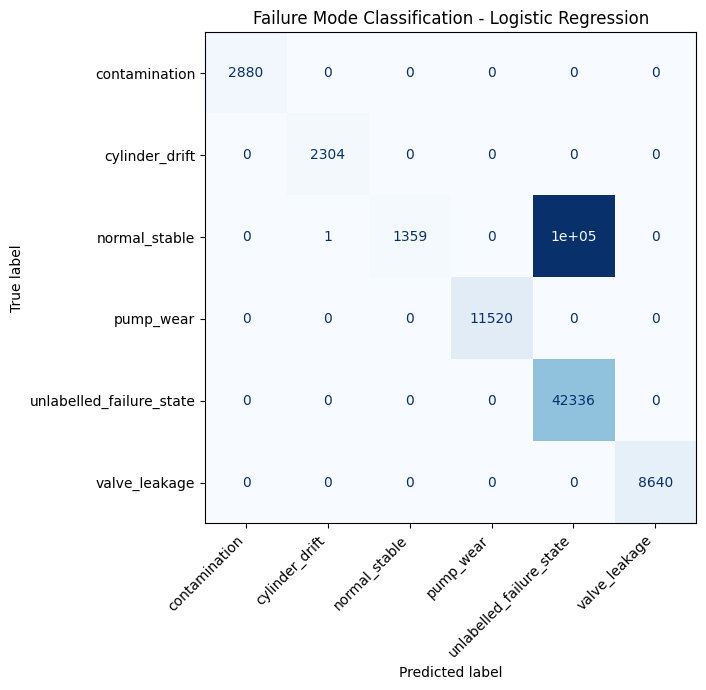

In [ ]:
# Confusion matrix for best failure mode model

cm = confusion_matrix(
    y_failure_mode_test_encoded,
    best_failure_mode_predictions
)

fig, ax = plt.subplots(figsize=(9, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=failure_mode_encoder.classes_
)

disp.plot(ax=ax, cmap="Blues", colorbar=False)

ax.set_title(f"Failure Mode Classification - {best_failure_mode_model_name}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Observation** : Our model did very well on the named failure types:

contamination
cylinder_drift
pump_wear
valve_leakage

For those, Logistic Regression got almost perfect results. But it failed badly on this class:

**normal_stable**

From your classification report:

normal_stable recall = 0.01

That means:Out of all true normal/stable readings, the model only correctly recognised about 1%.
In your confusion matrix, most normal_stable rows were wrongly predicted as:

**unlabelled_failure_state**

So in business terms:

The model is over-warning. It is treating many stable readings as failure-state readings. That would create a lot of false alarms in a real predictive maintenance system.

For the Accuracy:

Your Dummy Baseline has:
Accuracy = 0.61

Logistic Regression has:
Accuracy = 0.40

So the simple dummy model has higher accuracy. But the dummy model is useless because it probably just predicts the biggest class most of the time. That is why we used F1 Macro, which treats small classes more fairly. But even though Logistic Regression has the best F1 Macro, it still has a serious weakness:

**It cannot properly separate normal_stable from unlabelled_failure_state.**

**Next Steps** : The problem is the target design.

unlabelled_failure_state is not really a failure mode. It is more like a condition state. So mixing it with actual failure modes makes the classification task messy.

**Better correction**

We would split this into two cleaner modelling tasks:

**Task 1**: Known failure mode classification
Only classify actual named failure modes:
pump_wear, valve_leakage, contamination, cylinder_drift

**Task 2**: RUL / risk status prediction
Predict stable, degrading, watch, high risk, failure imminent, failure now

In [ ]:
# KNOWN FAILURE MODE CLASSIFICATION ONLY

# Keep only rows where the original failure_mode is known.
known_failure_df = df_model[df_model["failure_mode"].notna()].copy()

print("Known failure rows:", known_failure_df.shape)

print("\nKnown failure mode distribution:")
display(known_failure_df["failure_mode"].value_counts())

Known failure rows: (126720, 52)

Known failure mode distribution:


,count
failure_mode,
pump_wear,57600
valve_leakage,43200
contamination,14400
cylinder_drift,11520


In [ ]:
# Prepare known failure mode features and target

# Use the same feature columns from Stage 6B.
X_known_failure = known_failure_df[feature_cols]

# Target is the original known failure_mode.
y_known_failure = known_failure_df["failure_mode"]

print("X_known_failure shape:", X_known_failure.shape)
print("y_known_failure shape:", y_known_failure.shape)

X_known_failure shape: (126720, 46)
y_known_failure shape: (126720,)


In [ ]:
# Class-wise time split for known failure modes

known_split_df = known_failure_df[["timestamp", "failure_mode"]].copy()

known_split_df = known_split_df.sort_values(
    ["failure_mode", "timestamp"]
)

known_split_df["class_row_number"] = (
    known_split_df
    .groupby("failure_mode")
    .cumcount()
)

known_split_df["class_total_rows"] = (
    known_split_df
    .groupby("failure_mode")["failure_mode"]
    .transform("count")
)

known_split_df["is_train"] = (
    known_split_df["class_row_number"]
    < 0.8 * known_split_df["class_total_rows"]
)

known_train_mask = known_split_df["is_train"].reindex(known_failure_df.index)
known_test_mask = ~known_train_mask

X_train_known_failure = X_known_failure.loc[known_train_mask]
X_test_known_failure = X_known_failure.loc[known_test_mask]

y_train_known_failure = y_known_failure.loc[known_train_mask]
y_test_known_failure = y_known_failure.loc[known_test_mask]

print("Known failure X_train shape:", X_train_known_failure.shape)
print("Known failure X_test shape:", X_test_known_failure.shape)

print("\nKnown failure distribution - TRAIN:")
display(y_train_known_failure.value_counts())

print("\nKnown failure distribution - TEST:")
display(y_test_known_failure.value_counts())

Known failure X_train shape: (101376, 46)
Known failure X_test shape: (25344, 46)

Known failure distribution - TRAIN:


,count
failure_mode,
pump_wear,46080
valve_leakage,34560
contamination,11520
cylinder_drift,9216



Known failure distribution - TEST:


,count
failure_mode,
pump_wear,11520
valve_leakage,8640
contamination,2880
cylinder_drift,2304


In [ ]:
# Encode known failure mode target

known_failure_encoder = LabelEncoder()

y_train_known_failure_encoded = known_failure_encoder.fit_transform(y_train_known_failure)
y_test_known_failure_encoded = known_failure_encoder.transform(y_test_known_failure)

known_failure_mapping = dict(
    zip(
        known_failure_encoder.classes_,
        known_failure_encoder.transform(known_failure_encoder.classes_)
    )
)

print("Known failure mode encoding:")
print(known_failure_mapping)

Known failure mode encoding:
{'contamination': np.int64(0), 'cylinder_drift': np.int64(1), 'pump_wear': np.int64(2), 'valve_leakage': np.int64(3)}


In [ ]:
# TRAIN KNOWN FAILURE MODE CLASSIFIER


from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Define known failure mode models

known_failure_models = {

    "Dummy Baseline": DummyClassifier(
        strategy="most_frequent"
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=18,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    )
}

print("Known failure mode models defined successfully.")

Known failure mode models defined successfully.


In [ ]:
from sklearn.pipeline import Pipeline

In [ ]:
# Train and evaluate known failure mode models


known_failure_results = {}

for model_name, model in known_failure_models.items():

    print(f"\nTraining: {model_name}")

    model_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    model_pipeline.fit(
        X_train_known_failure,
        y_train_known_failure_encoded
    )

    y_pred = model_pipeline.predict(X_test_known_failure)

    accuracy = accuracy_score(y_test_known_failure_encoded, y_pred)

    precision_weighted = precision_score(
        y_test_known_failure_encoded,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall_weighted = recall_score(
        y_test_known_failure_encoded,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1_weighted = f1_score(
        y_test_known_failure_encoded,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1_macro = f1_score(
        y_test_known_failure_encoded,
        y_pred,
        average="macro",
        zero_division=0
    )

    known_failure_results[model_name] = {
        "Accuracy": accuracy,
        "Precision Weighted": precision_weighted,
        "Recall Weighted": recall_weighted,
        "F1 Weighted": f1_weighted,
        "F1 Macro": f1_macro,
        "Model": model_pipeline,
        "Predictions": y_pred
    }

    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Weighted: {f1_weighted:.4f}")
    print(f"F1 Macro: {f1_macro:.4f}")


Training: Dummy Baseline
Accuracy: 0.4545
F1 Weighted: 0.2841
F1 Macro: 0.1562

Training: Logistic Regression
Accuracy: 0.9977
F1 Weighted: 0.9977
F1 Macro: 0.9961

Training: Random Forest
Accuracy: 0.9470
F1 Weighted: 0.9386
F1 Macro: 0.8886


In [ ]:
# Compare known failure mode model results

known_failure_results_df = (
    pd.DataFrame(known_failure_results)
      .T
      .drop(columns=["Model", "Predictions"])
      .sort_values("F1 Macro", ascending=False)
)

display(known_failure_results_df)

best_known_failure_model_name = known_failure_results_df.index[0]
best_known_failure_model = known_failure_results[best_known_failure_model_name]["Model"]
best_known_failure_predictions = known_failure_results[best_known_failure_model_name]["Predictions"]

print("Best known failure mode model:", best_known_failure_model_name)

,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted,F1 Macro
Logistic Regression,1.00,1.00,1.00,1.00,1.00
Random Forest,0.95,0.95,0.95,0.94,0.89
Dummy Baseline,0.45,0.21,0.45,0.28,0.16


Best known failure mode model: Logistic Regression


In [ ]:
# Detailed classification report

print("Best known failure mode model:", best_known_failure_model_name)

print(
    classification_report(
        y_test_known_failure_encoded,
        best_known_failure_predictions,
        target_names=known_failure_encoder.classes_,
        zero_division=0
    )
)

Best known failure mode model: Logistic Regression
                precision    recall  f1-score   support

 contamination       1.00      1.00      1.00      2880
cylinder_drift       1.00      0.97      0.99      2304
     pump_wear       0.99      1.00      1.00     11520
 valve_leakage       1.00      1.00      1.00      8640

      accuracy                           1.00     25344
     macro avg       1.00      0.99      1.00     25344
  weighted avg       1.00      1.00      1.00     25344



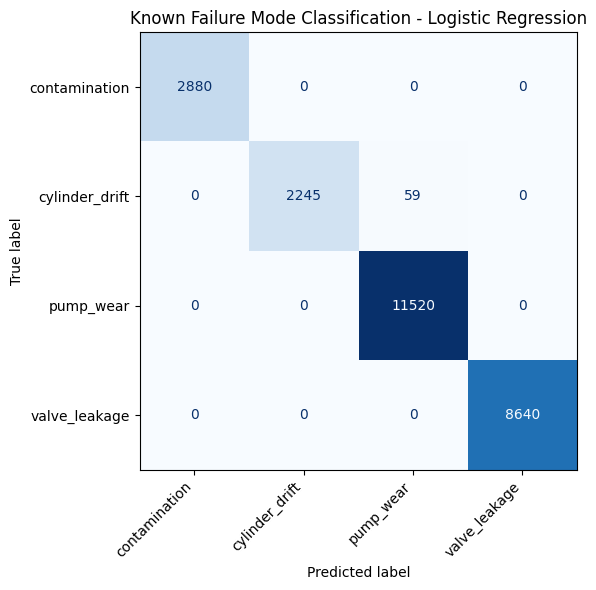

In [ ]:
# Confusion matrix

cm = confusion_matrix(
    y_test_known_failure_encoded,
    best_known_failure_predictions
)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=known_failure_encoder.classes_
)

disp.plot(ax=ax, cmap="Blues", colorbar=False)

ax.set_title(f"Known Failure Mode Classification - {best_known_failure_model_name}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Observation :

Known Failure Mode Classification:
Best model = Logistic Regression

Accuracy = 99.77%

F1 Macro = 99.61%

Purpose:
Predict the type of known hydraulic failure once the system is already in a failure/degradation window.

In [ ]:
# STAGE 10: RUL REGRESSION MODELS

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np
import pandas as pd

In [ ]:
# Define RUL regression models

rul_models = {

    "Dummy Baseline": DummyRegressor(
        strategy="mean"
    ),

    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(
        alpha=1.0
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=18,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
}

print("RUL regression models defined successfully.")

RUL regression models defined successfully.


In [ ]:
# Train and evaluate RUL regression models

rul_results = {}

for model_name, model in rul_models.items():

    print(f"\nTraining: {model_name}")

    model_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    model_pipeline.fit(X_train, y_rul_train)

    y_pred = model_pipeline.predict(X_test)

    mae = mean_absolute_error(y_rul_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_rul_test, y_pred))
    r2 = r2_score(y_rul_test, y_pred)

    rul_results[model_name] = {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Model": model_pipeline,
        "Predictions": y_pred
    }

    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2: {r2:.4f}")


Training: Dummy Baseline
MAE: 343.37
RMSE: 354.63
R2: -4.5089

Training: Linear Regression
MAE: 203.52
RMSE: 213.17
R2: -0.9905

Training: Ridge Regression
MAE: 203.45
RMSE: 213.06
R2: -0.9885

Training: Random Forest
MAE: 97.71
RMSE: 186.97
R2: -0.5313


**Observation :**   
**Linear Regression / Ridge Regression**

MAE: about 203 hours

R2: about -0.99

These models improved compared with the dummy baseline, but they are still weak. The straight-line models cannot properly understand the RUL pattern.

That makes sense because our data is not a simple straight-line problem. The RUL has a lot of:

500 = stable/capped value

0 = failure point

middle values = degradation period

**Random Forest**

MAE: 97.71

RMSE: 186.97

R2: -0.5313

Random Forest is the best of the models tested so far because it has the lowest error. Random Forest is much better than the simple models, but it is still not strong enough.

The MAE means:

On average, the Random Forest model is about 98 RUL hours away from the true value. That is an improvement, but not yet ideal for a predictive maintenance project.

The biggest issue: negative R²

Your R² values are negative:

Dummy Baseline: -4.5089

Linear Regression: -0.9905

Ridge Regression: -0.9885

Random Forest: -0.5313


The model is struggling to explain the RUL values in the test set. It means the current RUL regression setup is not yet the best setup.

The main reason is what we saw earlier:

Training set median RUL = 500

Test set median RUL = 0

So the model trained mostly on healthier/stable readings, then got tested mostly on late-failure readings. The model studied mostly healthy machine behaviour, then the exam mostly asked about failure-stage behaviour.

That is a very hard test.

**Suggestion**

Our current best baseline RUL model is:

Random Forest

MAE = 97.71 hours

RMSE = 186.97 hours

R² = -0.5313

Now we should improve the RUL approach.

**Better modelling logic**

Because RUL = 500 appears to mean “stable / capped maximum RUL”, we should not force one regression model to learn both:

stable capped values = 500
failure countdown values = 0–499

**A better setup is:**

Model 1: RUL status classification
Predict stable, degrading, watch, high risk, failure imminent, failure now.

Model 2: RUL regression
Only predict exact RUL hours for non-stable/degradation rows.

In [ ]:
# RUL MODEL DIAGNOSTICS

rul_results_df = (
    pd.DataFrame(rul_results)
      .T
      .drop(columns=["Model", "Predictions"])
      .sort_values("MAE", ascending=True)
)

display(rul_results_df)

best_rul_model_name = rul_results_df.index[0]
best_rul_model = rul_results[best_rul_model_name]["Model"]
best_rul_predictions = rul_results[best_rul_model_name]["Predictions"]

print("Best RUL model:", best_rul_model_name)

# Compare actual and predicted RUL summary
prediction_check = pd.DataFrame({
    "actual_rul": y_rul_test.values,
    "predicted_rul": best_rul_predictions
})

display(prediction_check.describe().round(2))

,MAE,RMSE,R2
Random Forest,97.71,186.97,-0.53
Ridge Regression,203.45,213.06,-0.99
Linear Regression,203.52,213.17,-0.99
Dummy Baseline,343.37,354.63,-4.51


Best RUL model: Random Forest


,actual_rul,predicted_rul
count,"172,800.00","172,800.00"
mean,66.50,147.72
std,151.09,191.48
min,0.00,0.00
25%,0.00,0.00
50%,0.00,39.20
75%,24.00,314.85
max,500.00,500.00


In [ ]:
# Check prediction error by actual RUL status
rul_diagnostic_df = df_model.loc[test_mask, ["timestamp", "machine_id", "rul_hours", "rul_status_model"]].copy()

rul_diagnostic_df["predicted_rul"] = best_rul_predictions
rul_diagnostic_df["absolute_error"] = abs(
    rul_diagnostic_df["rul_hours"] - rul_diagnostic_df["predicted_rul"]
)

error_by_status = (
    rul_diagnostic_df
    .groupby("rul_status_model")["absolute_error"]
    .agg(["count", "mean", "median", "max"])
    .round(2)
    .reset_index()
)

display(error_by_status)

,rul_status_model,count,mean,median,max
0,degrading,10074,83.34,91.96,183.96
1,failure_imminent,4320,74.55,74.27,284.01
2,failure_now,125286,114.65,0.40,500.00
3,high_risk,4323,64.94,57.43,221.15
4,stable,17280,26.39,0.00,488.38
5,watch,11517,54.03,52.84,167.65


**RUL regression diagnostic summary:**

Random Forest was the best RUL regression model, but exact RUL prediction remains weak.

It achieved MAE = 97.71 hours, RMSE = 186.97 hours, and R² = -0.53. The model generally overestimated remaining useful life, predicting an average RUL of 147.72 hours compared with the actual test average of 66.50 hours.

This is risky in predictive maintenance because overestimating RUL could delay maintenance action.

Error analysis showed the model performed reasonably on many stable and failure-now rows, but struggled with the transition stages such as degrading, watch, high risk, and failure imminent.

Therefore, exact RUL regression is kept as a baseline, while RUL status classification is a more practical next step.


In [ ]:
# STAGE 11: RUL STATUS CLASSIFICATION MODELS

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Define RUL status classification models

rul_status_models = {

    "Dummy Baseline": DummyClassifier(
        strategy="most_frequent"
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=18,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    )
}

print("RUL status classification models defined successfully.")

RUL status classification models defined successfully.


In [ ]:
# Train and evaluate RUL status models

rul_status_results = {}

for model_name, model in rul_status_models.items():

    print(f"\nTraining: {model_name}")

    model_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    model_pipeline.fit(X_train, y_rul_status_train_encoded)

    y_pred = model_pipeline.predict(X_test)

    accuracy = accuracy_score(y_rul_status_test_encoded, y_pred)

    precision_weighted = precision_score(
        y_rul_status_test_encoded,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall_weighted = recall_score(
        y_rul_status_test_encoded,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1_weighted = f1_score(
        y_rul_status_test_encoded,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1_macro = f1_score(
        y_rul_status_test_encoded,
        y_pred,
        average="macro",
        zero_division=0
    )

    rul_status_results[model_name] = {
        "Accuracy": accuracy,
        "Precision Weighted": precision_weighted,
        "Recall Weighted": recall_weighted,
        "F1 Weighted": f1_weighted,
        "F1 Macro": f1_macro,
        "Model": model_pipeline,
        "Predictions": y_pred
    }

    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Weighted: {f1_weighted:.4f}")
    print(f"F1 Macro: {f1_macro:.4f}")


Training: Dummy Baseline
Accuracy: 0.1000
F1 Weighted: 0.0182
F1 Macro: 0.0303

Training: Logistic Regression
Accuracy: 0.7500
F1 Weighted: 0.6861
F1 Macro: 0.2027

Training: Random Forest
Accuracy: 0.7166
F1 Weighted: 0.7475
F1 Macro: 0.5611


In [ ]:
# Compare RUL status model results

rul_status_results_df = (
    pd.DataFrame(rul_status_results)
      .T
      .drop(columns=["Model", "Predictions"])
      .sort_values("F1 Macro", ascending=False)
)

display(rul_status_results_df)

best_rul_status_model_name = rul_status_results_df.index[0]
best_rul_status_model = rul_status_results[best_rul_status_model_name]["Model"]
best_rul_status_predictions = rul_status_results[best_rul_status_model_name]["Predictions"]

print("Best RUL status model:", best_rul_status_model_name)

,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted,F1 Macro
Random Forest,0.72,0.85,0.72,0.75,0.56
Logistic Regression,0.75,0.72,0.75,0.69,0.20
Dummy Baseline,0.10,0.01,0.10,0.02,0.03


Best RUL status model: Random Forest


In [ ]:
# Detailed RUL status classification report

print("Best RUL status model:", best_rul_status_model_name)

print(
    classification_report(
        y_rul_status_test_encoded,
        best_rul_status_predictions,
        target_names=rul_status_encoder.classes_,
        zero_division=0
    )
)

Best RUL status model: Random Forest
                  precision    recall  f1-score   support

       degrading       0.71      0.98      0.82     10074
failure_imminent       0.62      0.36      0.45      4320
     failure_now       0.99      0.72      0.83    125286
       high_risk       0.33      0.45      0.38      4323
          stable       0.32      0.96      0.48     17280
           watch       0.49      0.34      0.40     11517

        accuracy                           0.72    172800
       macro avg       0.58      0.63      0.56    172800
    weighted avg       0.85      0.72      0.75    172800



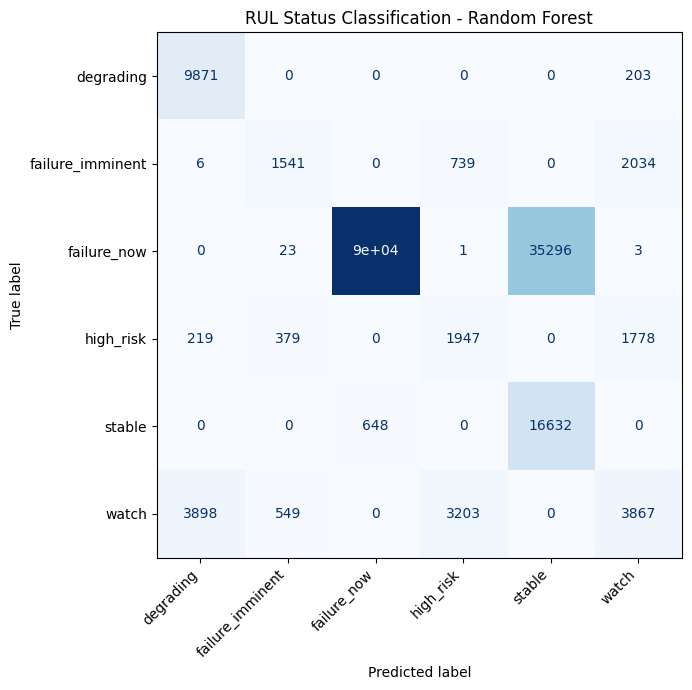

In [ ]:
# RUL status confusion matrix

cm = confusion_matrix(
    y_rul_status_test_encoded,
    best_rul_status_predictions
)

fig, ax = plt.subplots(figsize=(9, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rul_status_encoder.classes_
)

disp.plot(ax=ax, cmap="Blues", colorbar=False)

ax.set_title(f"RUL Status Classification - {best_rul_status_model_name}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**RUL status classification summary:**

Random Forest was selected as the best RUL status model because it handled smaller classes better than Logistic Regression.

It achieved Accuracy = 71.66%, F1 Weighted = 74.75%, and F1 Macro = 56.11%. The model performed well on broader conditions such as degrading and failure_now, but struggled to separate middle-risk stages like watch, high_risk, and failure_imminent.

The confusion matrix also showed some risky misclassification between failure_now and stable. Therefore, this model is useful as a baseline, but not production-ready.

Next step: simplify the six RUL status classes into three business-friendly risk groups:

Stable, Warning, and Critical.


In [ ]:
# SIMPLIFIED RUL RISK TARGET

df_model["rul_risk_3class"] = np.select(
    [
        df_model["rul_status_model"] == "stable",
        df_model["rul_status_model"].isin(["degrading", "watch"]),
        df_model["rul_status_model"].isin(["high_risk", "failure_imminent", "failure_now"])
    ],
    [
        "Stable",
        "Warning",
        "Critical"
    ],
    default="Unknown"
)

print("Simplified RUL risk distribution:")
display(df_model["rul_risk_3class"].value_counts())

Simplified RUL risk distribution:


,count
rul_risk_3class,
Stable,525600
Critical,237627
Warning,100773


In [ ]:
# Split simplified RUL risk target using the same global time split

y_rul_risk_3class = df_model["rul_risk_3class"]

y_rul_risk_train = y_rul_risk_3class.loc[train_mask]
y_rul_risk_test = y_rul_risk_3class.loc[test_mask]

print("Train distribution:")
display(y_rul_risk_train.value_counts())

print("\nTest distribution:")
display(y_rul_risk_test.value_counts())

Train distribution:


,count
rul_risk_3class,
Stable,508320
Critical,103698
Warning,79182



Test distribution:


,count
rul_risk_3class,
Critical,133929
Warning,21591
Stable,17280


**Simplified RUL risk target summary:**

The original six RUL status classes were grouped into three dashboard-friendly risk levels:

Stable, Warning, and Critical.

Stable represents healthy machine behaviour, Warning represents degradation or monitoring needs, and Critical represents high-risk, failure-imminent, or failed conditions. This 3-class target is easier to explain in Power BI and more practical for maintenance decisions.

The train/test split remains challenging because the training set is mostly stable, while the test set is mostly critical, reflecting how later time periods move closer to failure.

This simplified target is therefore preferred over exact RUL prediction for the final dashboard model.


In [ ]:
# TRAIN 3-CLASS RUL RISK MODEL

from sklearn.preprocessing import LabelEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Encode 3-class target

rul_risk_encoder = LabelEncoder()

y_rul_risk_train_encoded = rul_risk_encoder.fit_transform(y_rul_risk_train)
y_rul_risk_test_encoded = rul_risk_encoder.transform(y_rul_risk_test)

rul_risk_mapping = dict(
    zip(
        rul_risk_encoder.classes_,
        rul_risk_encoder.transform(rul_risk_encoder.classes_)
    )
)

print("3-class RUL risk encoding:")
print(rul_risk_mapping)

3-class RUL risk encoding:
{'Critical': np.int64(0), 'Stable': np.int64(1), 'Warning': np.int64(2)}


In [ ]:
# Define 3-class models

rul_risk_models = {

    "Dummy Baseline": DummyClassifier(
        strategy="most_frequent"
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=18,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    )
}

print("3-class RUL risk models defined successfully.")

3-class RUL risk models defined successfully.


In [ ]:
# Train and evaluate 3-class RUL risk models

rul_risk_results = {}

for model_name, model in rul_risk_models.items():

    print(f"\nTraining: {model_name}")

    model_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    model_pipeline.fit(X_train, y_rul_risk_train_encoded)

    y_pred = model_pipeline.predict(X_test)

    accuracy = accuracy_score(y_rul_risk_test_encoded, y_pred)

    precision_weighted = precision_score(
        y_rul_risk_test_encoded,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall_weighted = recall_score(
        y_rul_risk_test_encoded,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1_weighted = f1_score(
        y_rul_risk_test_encoded,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1_macro = f1_score(
        y_rul_risk_test_encoded,
        y_pred,
        average="macro",
        zero_division=0
    )

    rul_risk_results[model_name] = {
        "Accuracy": accuracy,
        "Precision Weighted": precision_weighted,
        "Recall Weighted": recall_weighted,
        "F1 Weighted": f1_weighted,
        "F1 Macro": f1_macro,
        "Model": model_pipeline,
        "Predictions": y_pred
    }

    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Weighted: {f1_weighted:.4f}")
    print(f"F1 Macro: {f1_macro:.4f}")


Training: Dummy Baseline
Accuracy: 0.1000
F1 Weighted: 0.0182
F1 Macro: 0.0606

Training: Logistic Regression
Accuracy: 0.7946
F1 Weighted: 0.7192
F1 Macro: 0.3877

Training: Random Forest
Accuracy: 0.7609
F1 Weighted: 0.7936
F1 Macro: 0.7248


In [ ]:
# Compare 3-class model results

rul_risk_results_df = (
    pd.DataFrame(rul_risk_results)
      .T
      .drop(columns=["Model", "Predictions"])
      .sort_values("F1 Macro", ascending=False)
)

display(rul_risk_results_df)

best_rul_risk_model_name = rul_risk_results_df.index[0]
best_rul_risk_model = rul_risk_results[best_rul_risk_model_name]["Model"]
best_rul_risk_predictions = rul_risk_results[best_rul_risk_model_name]["Predictions"]

print("Best 3-class RUL risk model:", best_rul_risk_model_name)

,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted,F1 Macro
Random Forest,0.76,0.89,0.76,0.79,0.72
Logistic Regression,0.79,0.76,0.79,0.72,0.39
Dummy Baseline,0.10,0.01,0.10,0.02,0.06


Best 3-class RUL risk model: Random Forest


In [ ]:
# Detailed 3-class classification report

print("Best 3-class RUL risk model:", best_rul_risk_model_name)

print(
    classification_report(
        y_rul_risk_test_encoded,
        best_rul_risk_predictions,
        target_names=rul_risk_encoder.classes_,
        zero_division=0
    )
)

Best 3-class RUL risk model: Random Forest
              precision    recall  f1-score   support

    Critical       0.97      0.71      0.82    133929
      Stable       0.33      0.97      0.49     17280
     Warning       0.83      0.91      0.87     21591

    accuracy                           0.76    172800
   macro avg       0.71      0.86      0.72    172800
weighted avg       0.89      0.76      0.79    172800



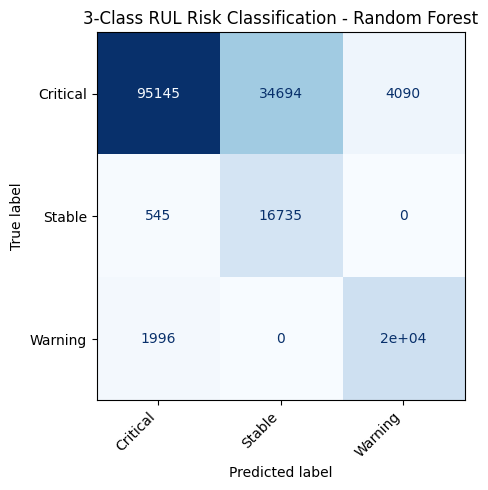

In [ ]:
# 3-class RUL risk confusion matrix

cm = confusion_matrix(
    y_rul_risk_test_encoded,
    best_rul_risk_predictions
)

fig, ax = plt.subplots(figsize=(7, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rul_risk_encoder.classes_
)

disp.plot(ax=ax, cmap="Blues", colorbar=False)

ax.set_title(f"3-Class RUL Risk Classification - {best_rul_risk_model_name}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**3-class RUL risk classification summary:**

 The simplified Stable / Warning / Critical model performed better than exact RUL regression and the earlier 6-class RUL status model.

 Random Forest was selected as the best model with Accuracy = 76.09%, F1 Weighted = 79.36%, and F1 Macro = 72.48%. The model performed well for Critical and Warning classes, but the confusion matrix showed that some true Critical readings were incorrectly predicted as Stable.

This is risky in a predictive maintenance setting, so the model is useful as a strong baseline but should be supported by a safety-focused Critical vs Non-Critical classifier.


In [ ]:
# This model answers the most important maintenance question:
#Is the machine currently in a critical condition or not?

# CRITICAL VS NON-CRITICAL TARGET

# Create binary safety target.
# Critical = 1
# Non-Critical = 0

df_model["critical_binary"] = np.where(
    df_model["rul_risk_3class"] == "Critical",
    1,
    0
)

print("Critical vs Non-Critical distribution:")
display(df_model["critical_binary"].value_counts())

print("\nLabel meaning:")
print("0 = Non-Critical")
print("1 = Critical")

Critical vs Non-Critical distribution:


,count
critical_binary,
0,626373
1,237627



Label meaning:
0 = Non-Critical
1 = Critical


In [ ]:
# Split binary critical target

y_critical = df_model["critical_binary"]

y_critical_train = y_critical.loc[train_mask]
y_critical_test = y_critical.loc[test_mask]

print("Train distribution:")
display(y_critical_train.value_counts())

print("\nTest distribution:")
display(y_critical_test.value_counts())

Train distribution:


,count
critical_binary,
0,587502
1,103698



Test distribution:


,count
critical_binary,
1,133929
0,38871


In [ ]:
# TRAIN CRITICAL VS NON-CRITICAL MODELS

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Define binary classification models

critical_models = {

    "Dummy Baseline": DummyClassifier(
        strategy="most_frequent"
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=18,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    )
}

print("Critical vs Non-Critical models defined successfully.")

Critical vs Non-Critical models defined successfully.


In [ ]:
# Train and evaluate binary models

critical_results = {}

for model_name, model in critical_models.items():

    print(f"\nTraining: {model_name}")

    model_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    model_pipeline.fit(X_train, y_critical_train)

    y_pred = model_pipeline.predict(X_test)

    # Probability of Critical class, where possible.
    if hasattr(model_pipeline.named_steps["model"], "predict_proba"):
        y_proba = model_pipeline.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_critical_test, y_proba)
    else:
        y_proba = None
        auc = np.nan

    accuracy = accuracy_score(y_critical_test, y_pred)

    precision = precision_score(
        y_critical_test,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    recall = recall_score(
        y_critical_test,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    f1 = f1_score(
        y_critical_test,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    critical_results[model_name] = {
        "Accuracy": accuracy,
        "Critical Precision": precision,
        "Critical Recall": recall,
        "Critical F1": f1,
        "ROC AUC": auc,
        "Model": model_pipeline,
        "Predictions": y_pred,
        "Probabilities": y_proba
    }

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Critical Precision: {precision:.4f}")
    print(f"Critical Recall: {recall:.4f}")
    print(f"Critical F1: {f1:.4f}")
    print(f"ROC AUC: {auc:.4f}")


Training: Dummy Baseline
Accuracy: 0.2249
Critical Precision: 0.0000
Critical Recall: 0.0000
Critical F1: 0.0000
ROC AUC: 0.5000

Training: Logistic Regression
Accuracy: 0.7954
Critical Precision: 0.7912
Critical Recall: 0.9999
Critical F1: 0.8834
ROC AUC: 0.7978

Training: Random Forest
Accuracy: 0.7256
Critical Precision: 0.9922
Critical Recall: 0.6511
Critical F1: 0.7863
ROC AUC: 0.8761


In [ ]:
# Compare binary model results

critical_results_df = (
    pd.DataFrame(critical_results)
      .T
      .drop(columns=["Model", "Predictions", "Probabilities"])
      .sort_values("Critical Recall", ascending=False)
)

display(critical_results_df)

best_critical_model_name = critical_results_df.index[0]
best_critical_model = critical_results[best_critical_model_name]["Model"]
best_critical_predictions = critical_results[best_critical_model_name]["Predictions"]
best_critical_probabilities = critical_results[best_critical_model_name]["Probabilities"]

print("Best Critical vs Non-Critical model:", best_critical_model_name)

,Accuracy,Critical Precision,Critical Recall,Critical F1,ROC AUC
Logistic Regression,0.80,0.79,1.00,0.88,0.80
Random Forest,0.73,0.99,0.65,0.79,0.88
Dummy Baseline,0.22,0.00,0.00,0.00,0.50


Best Critical vs Non-Critical model: Logistic Regression


In [ ]:
# Detailed binary classification report

print("Best Critical vs Non-Critical model:", best_critical_model_name)

print(
    classification_report(
        y_critical_test,
        best_critical_predictions,
        target_names=["Non-Critical", "Critical"],
        zero_division=0
    )
)

Best Critical vs Non-Critical model: Logistic Regression
              precision    recall  f1-score   support

Non-Critical       1.00      0.09      0.17     38871
    Critical       0.79      1.00      0.88    133929

    accuracy                           0.80    172800
   macro avg       0.89      0.55      0.52    172800
weighted avg       0.84      0.80      0.72    172800



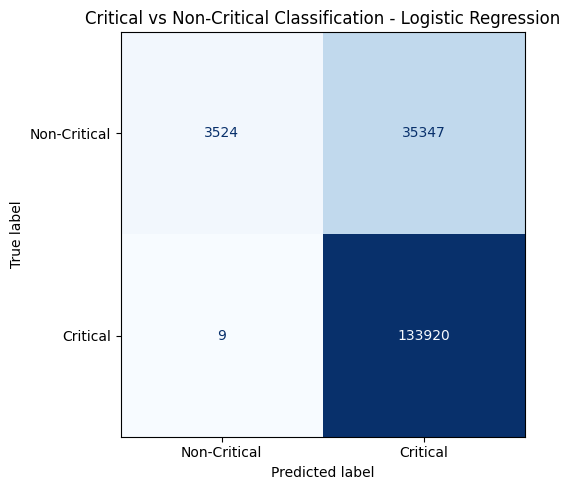

In [ ]:
# Critical vs Non-Critical confusion matrix

cm = confusion_matrix(
    y_critical_test,
    best_critical_predictions
)

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Critical", "Critical"]
)

disp.plot(ax=ax, cmap="Blues", colorbar=False)

ax.set_title(f"Critical vs Non-Critical Classification - {best_critical_model_name}")
plt.tight_layout()
plt.show()

Critical vs Non-Critical model summary:

Logistic Regression was selected as the best safety-focused model because it achieved very high Critical Recall.

The model correctly identified 133,920 out of 133,929 true critical readings, missing only 9 critical cases. This makes it useful for predictive maintenance because missing critical failures is more dangerous than raising extra warnings.

However, the model also produced many false alarms by classifying many non-critical readings as critical.

Therefore, this model is best interpreted as a safety-first alerting model rather than a production-ready final classifier.

In [ ]:
# EXPORT GLOBAL ML PREDICTIONS FOR POWER BI

# Create output using the global test rows.
powerbi_predictions = df_model.loc[test_mask, ["timestamp", "machine_id", "rul_hours", "rul_status_model", "rul_risk_3class", "critical_binary"]].copy()

# Add RUL regression prediction.
powerbi_predictions["predicted_rul_hours"] = best_rul_predictions

# Add RUL absolute error.
powerbi_predictions["rul_absolute_error"] = abs(
    powerbi_predictions["rul_hours"] - powerbi_predictions["predicted_rul_hours"]
)

# Add predicted 3-class RUL risk.
powerbi_predictions["predicted_rul_risk_3class"] = rul_risk_encoder.inverse_transform(
    best_rul_risk_predictions
)

# Add predicted critical flag.
powerbi_predictions["predicted_critical_binary"] = best_critical_predictions

# Add critical probability if available.
if best_critical_probabilities is not None:
    powerbi_predictions["predicted_critical_probability"] = best_critical_probabilities
else:
    powerbi_predictions["predicted_critical_probability"] = np.nan

# Add readable labels for critical model.
powerbi_predictions["actual_critical_label"] = np.where(
    powerbi_predictions["critical_binary"] == 1,
    "Critical",
    "Non-Critical"
)

powerbi_predictions["predicted_critical_label"] = np.where(
    powerbi_predictions["predicted_critical_binary"] == 1,
    "Critical",
    "Non-Critical"
)

# Add correctness flags.
powerbi_predictions["rul_risk_prediction_correct"] = (
    powerbi_predictions["rul_risk_3class"] == powerbi_predictions["predicted_rul_risk_3class"]
).astype(int)

powerbi_predictions["critical_prediction_correct"] = (
    powerbi_predictions["critical_binary"] == powerbi_predictions["predicted_critical_binary"]
).astype(int)

# Save to CSV.
powerbi_predictions.to_csv("ml_predictions_for_powerbi.csv", index=False)

print("Saved: ml_predictions_for_powerbi.csv")
display(powerbi_predictions.head())

Saved: ml_predictions_for_powerbi.csv


,timestamp,machine_id,rul_hours,rul_status_model,rul_risk_3class,critical_binary,predicted_rul_hours,rul_absolute_error,predicted_rul_risk_3class,predicted_critical_binary,predicted_critical_probability,actual_critical_label,predicted_critical_label,rul_risk_prediction_correct,critical_prediction_correct
69120,2024-02-18 00:00:00,HPU_01,0.00,failure_now,Critical,1,0.57,0.57,Critical,1,0.97,Critical,Critical,1,1
69121,2024-02-18 00:01:00,HPU_01,0.00,failure_now,Critical,1,1.58,1.58,Critical,1,0.99,Critical,Critical,1,1
69122,2024-02-18 00:02:00,HPU_01,0.00,failure_now,Critical,1,2.37,2.37,Critical,1,0.97,Critical,Critical,1,1
69123,2024-02-18 00:03:00,HPU_01,0.00,failure_now,Critical,1,1.87,1.87,Critical,1,0.99,Critical,Critical,1,1
69124,2024-02-18 00:04:00,HPU_01,0.00,failure_now,Critical,1,2.23,2.23,Critical,1,0.99,Critical,Critical,1,1


In [ ]:
# EXPORT KNOWN FAILURE MODE PREDICTIONS

known_failure_powerbi = known_failure_df.loc[known_test_mask, ["timestamp", "machine_id", "failure_mode", "rul_hours"]].copy()

known_failure_powerbi["predicted_failure_mode"] = known_failure_encoder.inverse_transform(
    best_known_failure_predictions
)

known_failure_powerbi["failure_mode_prediction_correct"] = (
    known_failure_powerbi["failure_mode"] == known_failure_powerbi["predicted_failure_mode"]
).astype(int)

known_failure_powerbi.to_csv("known_failure_mode_predictions_for_powerbi.csv", index=False)

print("Saved: known_failure_mode_predictions_for_powerbi.csv")
display(known_failure_powerbi.head())

Saved: known_failure_mode_predictions_for_powerbi.csv


,timestamp,machine_id,failure_mode,rul_hours,predicted_failure_mode,failure_mode_prediction_correct
159120,2024-02-20 12:00:00,HPU_02,valve_leakage,36.00,valve_leakage,1
159121,2024-02-20 12:01:00,HPU_02,valve_leakage,36.00,valve_leakage,1
159122,2024-02-20 12:02:00,HPU_02,valve_leakage,36.00,valve_leakage,1
159123,2024-02-20 12:03:00,HPU_02,valve_leakage,36.00,valve_leakage,1
159124,2024-02-20 12:04:00,HPU_02,valve_leakage,35.90,valve_leakage,1


In [ ]:
# EXPORT MODEL PERFORMANCE TABLES

# Known failure mode model results.
known_failure_results_df_export = known_failure_results_df.copy()
known_failure_results_df_export["model_task"] = "Known Failure Mode Classification"
known_failure_results_df_export["model_name"] = known_failure_results_df_export.index

# RUL regression results.
rul_results_df_export = rul_results_df.copy()
rul_results_df_export["model_task"] = "Exact RUL Regression"
rul_results_df_export["model_name"] = rul_results_df_export.index

# 3-class RUL risk results.
rul_risk_results_df_export = rul_risk_results_df.copy()
rul_risk_results_df_export["model_task"] = "3-Class RUL Risk Classification"
rul_risk_results_df_export["model_name"] = rul_risk_results_df_export.index

# Critical binary results.
critical_results_df_export = critical_results_df.copy()
critical_results_df_export["model_task"] = "Critical vs Non-Critical Classification"
critical_results_df_export["model_name"] = critical_results_df_export.index

# Save separate files.
known_failure_results_df_export.to_csv("known_failure_model_results.csv", index=False)
rul_results_df_export.to_csv("rul_regression_model_results.csv", index=False)
rul_risk_results_df_export.to_csv("rul_risk_3class_model_results.csv", index=False)
critical_results_df_export.to_csv("critical_binary_model_results.csv", index=False)

print("Saved model result CSV files.")

Saved model result CSV files.


In [ ]:
# SAVE BEST MODELS

import joblib

joblib.dump(best_known_failure_model, "best_known_failure_mode_classifier.pkl")
joblib.dump(best_rul_model, "best_rul_regression_model.pkl")
joblib.dump(best_rul_risk_model, "best_rul_risk_3class_classifier.pkl")
joblib.dump(best_critical_model, "best_critical_binary_classifier.pkl")

joblib.dump(known_failure_encoder, "known_failure_mode_encoder.pkl")
joblib.dump(rul_risk_encoder, "rul_risk_3class_encoder.pkl")

print("Saved best models and encoders.")

Saved best models and encoders.


In [ ]:
# DOWNLOAD FINAL OUTPUTS

from google.colab import files

files.download("ml_predictions_for_powerbi.csv")
files.download("known_failure_mode_predictions_for_powerbi.csv")

files.download("known_failure_model_results.csv")
files.download("rul_regression_model_results.csv")
files.download("rul_risk_3class_model_results.csv")
files.download("critical_binary_model_results.csv")

files.download("best_known_failure_mode_classifier.pkl")
files.download("best_rul_regression_model.pkl")
files.download("best_rul_risk_3class_classifier.pkl")
files.download("best_critical_binary_classifier.pkl")

files.download("known_failure_mode_encoder.pkl")
files.download("rul_risk_3class_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# COMBINE MODEL PERFORMANCE TABLES

combined_model_results = pd.concat(
    [
        known_failure_results_df_export,
        rul_results_df_export,
        rul_risk_results_df_export,
        critical_results_df_export
    ],
    ignore_index=True
)

combined_model_results.to_csv("combined_model_performance_results.csv", index=False)

print("Saved: combined_model_performance_results.csv")
display(combined_model_results.head())

# NaN values are expected in the combined model results table because different model tasks use different metrics.
# Classification models use Accuracy, Precision, Recall and F1 scores, while regression models use MAE, RMSE and R².
# The blank values do not mean the model failed; they mean that metric is not relevant for that model type.

Saved: combined_model_performance_results.csv


,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted,F1 Macro,model_task,model_name,MAE,RMSE,R2,Critical Precision,Critical Recall,Critical F1,ROC AUC
0,1.00,1.00,1.00,1.00,1.00,Known Failure Mode Classification,Logistic Regression,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.95,0.95,0.95,0.94,0.89,Known Failure Mode Classification,Random Forest,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.45,0.21,0.45,0.28,0.16,Known Failure Mode Classification,Dummy Baseline,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,Exact RUL Regression,Random Forest,97.71,186.97,-0.53,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,Exact RUL Regression,Ridge Regression,203.45,213.06,-0.99,NaN,NaN,NaN,NaN


In [ ]:
#from google.colab import files

#files.download("combined_model_performance_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# CREATE LONG-FORMAT MODEL METRICS TABLE FOR POWER BI

model_metrics_long = combined_model_results.melt(
    id_vars=["model_task", "model_name"],
    var_name="metric_name",
    value_name="metric_value"
)

# Remove metrics that do not apply to a model task.
model_metrics_long = model_metrics_long.dropna(subset=["metric_value"])

# Save long-format table.
model_metrics_long.to_csv("model_metrics_long_for_powerbi.csv", index=False)

print("Saved: model_metrics_long_for_powerbi.csv")
display(model_metrics_long.head(20))

Saved: model_metrics_long_for_powerbi.csv


,model_task,model_name,metric_name,metric_value
0,Known Failure Mode Classification,Logistic Regression,Accuracy,1.00
1,Known Failure Mode Classification,Random Forest,Accuracy,0.95
2,Known Failure Mode Classification,Dummy Baseline,Accuracy,0.45
7,3-Class RUL Risk Classification,Random Forest,Accuracy,0.76
8,3-Class RUL Risk Classification,Logistic Regression,Accuracy,0.79
9,3-Class RUL Risk Classification,Dummy Baseline,Accuracy,0.10
10,Critical vs Non-Critical Classification,Logistic Regression,Accuracy,0.80
11,Critical vs Non-Critical Classification,Random Forest,Accuracy,0.73
12,Critical vs Non-Critical Classification,Dummy Baseline,Accuracy,0.22
13,Known Failure Mode Classification,Logistic Regression,Precision Weighted,1.00


In [ ]:
#from google.colab import files

#files.download("model_metrics_long_for_powerbi.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Final export summary:**

The ML outputs were exported for Power BI dashboarding.

ml_predictions_for_powerbi.csv contains row-level RUL, risk, and critical predictions.

known_failure_mode_predictions_for_powerbi.csv contains actual vs predicted known failure modes.

model_metrics_long_for_powerbi.csv stores all model metrics in long format, making it easier to compare models in Power BI.

These outputs will support the final ML dashboard page focused on failure mode prediction, RUL risk classification, and critical alert detection.

## Final ML Modelling Summary

This notebook developed a predictive maintenance ML pipeline for hydraulic systems using sensor telemetry, failure labels, maintenance context, and engineered time-series features.

The known failure mode classifier performed strongly, with Logistic Regression achieving approximately 99.77% accuracy on labelled failure records. This model is useful for identifying the type of known failure once the system is already in a failure/degradation window.

Exact RUL regression was tested using multiple models, but it performed weakly because the dataset contains many capped stable values and many zero-RUL failure states. Random Forest was the best RUL regression baseline, but the model still overestimated remaining useful life and struggled with transition stages.

RUL status classification provided a more practical alternative by grouping machine condition into risk categories. The simplified 3-class model : Stable, Warning, and Critical, was easier to explain and more suitable for dashboarding than exact RUL prediction.

The final safety-focused Critical vs Non-Critical model was the most operationally useful model. Logistic Regression achieved very high Critical Recall, correctly identifying almost all critical readings while only missing a small number of truly critical cases. Although it produced false alarms, this is acceptable for a safety-first predictive maintenance use case where missing critical failures is more costly than raising extra alerts.

Overall, the final modelling approach supports a practical predictive maintenance dashboard by combining failure mode classification, RUL risk classification, critical alert detection, and model performance reporting.


**MLflow experiment tracking**


In [ ]:
import mlflow
import mlflow.sklearn

Set up MLflow experiment

In [ ]:
# Use SQLite as the MLflow tracking backend.
# This avoids the newer MLflow error caused by using file:./mlruns.
mlflow.set_tracking_uri("sqlite:///mlflow.db")

# Create or select the experiment where all runs will be stored.
mlflow.set_experiment("Bosch Hydraulic Predictive Maintenance")

print("MLflow tracking is ready using SQLite backend.")

2026/07/01 12:42:03 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/01 12:42:03 INFO mlflow.store.db.utils: Updating database tables
2026/07/01 12:42:06 INFO mlflow.tracking.fluent: Experiment with name 'Bosch Hydraulic Predictive Maintenance' does not exist. Creating a new experiment.


MLflow tracking is ready using SQLite backend.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

classification_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=150,
        learning_rate=0.08,
        max_depth=5,
        eval_metric="mlogloss",
        random_state=42
    )
}

print("Classification models defined.")

Classification models defined.


In [ ]:
# Columns we should not use as model inputs.
# These are either IDs, timestamps, or target variables.
leakage_cols = [
    "reading_timestamp",
    "timestamp",
    "failure_mode",
    "rul_hours"
]

# Keep only columns that actually exist in df_model.
leakage_cols = [col for col in leakage_cols if col in df_model.columns]

# Create feature columns by removing leakage columns.
feature_cols = [col for col in df_model.columns if col not in leakage_cols]

# Feature matrix.
X = df_model[feature_cols]

# Classification target.
y_class_raw = df_model["failure_mode"]

# Regression target.
y_reg = df_model["rul_hours"]

print("Number of features:", len(feature_cols))
print("Feature columns created.")

Number of features: 51
Feature columns created.


In [ ]:
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()

y_class = target_encoder.fit_transform(y_class_raw)

class_mapping = dict(
    zip(
        target_encoder.classes_,
        target_encoder.transform(target_encoder.classes_)
    )
)

print("Failure mode encoding:")
print(class_mapping)

Failure mode encoding:
{'contamination': np.int64(0), 'cylinder_drift': np.int64(1), 'pump_wear': np.int64(2), 'valve_leakage': np.int64(3), nan: np.int64(4)}


In [ ]:
# Choose the correct timestamp column.
if "reading_timestamp" in df_model.columns:
    time_col = "reading_timestamp"
else:
    time_col = "timestamp"

# Make sure timestamp is datetime.
df_model[time_col] = pd.to_datetime(df_model[time_col], errors="coerce")

# Split based on time, not random rows.
split_date = df_model[time_col].quantile(0.8)

train_mask = df_model[time_col] <= split_date
test_mask = df_model[time_col] > split_date

# Convert y_class into a Series so it aligns with dataframe indexes.
y_class_series = pd.Series(y_class, index=df_model.index)

# Classification train/test sets.
X_train_c = X.loc[train_mask]
X_test_c = X.loc[test_mask]
y_train_c = y_class_series.loc[train_mask]
y_test_c = y_class_series.loc[test_mask]

# Regression train/test sets.
X_train_r = X.loc[train_mask]
X_test_r = X.loc[test_mask]
y_train_r = y_reg.loc[train_mask]
y_test_r = y_reg.loc[test_mask]

print("Classification training rows:", X_train_c.shape[0])
print("Classification test rows:", X_test_c.shape[0])
print("Regression training rows:", X_train_r.shape[0])
print("Regression test rows:", X_test_r.shape[0])
print("Split date:", split_date)

Classification training rows: 691200
Classification test rows: 172800
Regression training rows: 691200
Regression test rows: 172800
Split date: 2024-02-17 23:59:12


In [ ]:
# Check whether your model result tables already exist in memory.
print("Checking available result tables...")

try:
    display(classification_results_df.head())
    print("classification_results_df exists.")
except NameError:
    print("classification_results_df does not exist.")

try:
    display(regression_results_df.head())
    print("regression_results_df exists.")
except NameError:
    print("regression_results_df does not exist.")

Checking available result tables...
classification_results_df does not exist.
regression_results_df does not exist.


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving ml_predictions_for_powerbi.csv to ml_predictions_for_powerbi (1).csv
Saving combined_model_performance_results.csv to combined_model_performance_results (1).csv
Saving known_failure_mode_predictions_for_powerbi.csv to known_failure_mode_predictions_for_powerbi (1).csv
Saving model_metrics_long_for_powerbi.csv to model_metrics_long_for_powerbi (1).csv
Saving critical_binary_model_results.csv to critical_binary_model_results (1).csv
Saving known_failure_model_results.csv to known_failure_model_results (1).csv
Saving rul_regression_model_results.csv to rul_regression_model_results (1).csv
Saving rul_risk_3class_model_results.csv to rul_risk_3class_model_results (1).csv


In [ ]:
import os

for file in os.listdir():
    print(file)

.config
sensor_telemetry.csv
failure_labels.csv
ml_predictions_for_powerbi.csv
maintenance_log.csv
critical_binary_model_results (1).csv
rul_regression_model_results.csv
known_failure_model_results.csv
known_failure_model_results (1).csv
rul_risk_3class_model_results.csv
ml_predictions_for_powerbi (1).csv
known_failure_mode_encoder.pkl
best_rul_risk_3class_classifier.pkl
rul_risk_3class_encoder.pkl
known_failure_mode_predictions_for_powerbi (1).csv
combined_model_performance_results.csv
best_rul_regression_model.pkl
known_failure_mode_predictions_for_powerbi.csv
rul_risk_3class_model_results (1).csv
equipment_master.csv
model_metrics_long_for_powerbi (1).csv
mlflow.db
mlruns
best_critical_binary_classifier.pkl
rul_regression_model_results (1).csv
best_known_failure_mode_classifier.pkl
combined_model_performance_results (1).csv
critical_binary_model_results.csv
model_metrics_long_for_powerbi.csv
sample_data


In [ ]:
combined_results_df = pd.read_csv("combined_model_performance_results.csv")

display(combined_results_df.head())
display(combined_results_df.columns)

,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted,F1 Macro,model_task,model_name,MAE,RMSE,R2,Critical Precision,Critical Recall,Critical F1,ROC AUC
0,1.00,1.00,1.00,1.00,1.00,Known Failure Mode Classification,Logistic Regression,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.95,0.95,0.95,0.94,0.89,Known Failure Mode Classification,Random Forest,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.45,0.21,0.45,0.28,0.16,Known Failure Mode Classification,Dummy Baseline,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,Exact RUL Regression,Random Forest,97.71,186.97,-0.53,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,Exact RUL Regression,Ridge Regression,203.45,213.06,-0.99,NaN,NaN,NaN,NaN


Index(['Accuracy', 'Precision Weighted', 'Recall Weighted', 'F1 Weighted',
       'F1 Macro', 'model_task', 'model_name', 'MAE', 'RMSE', 'R2',
       'Critical Precision', 'Critical Recall', 'Critical F1', 'ROC AUC'],
      dtype='object')

In [ ]:
# End any active MLflow run safely.
try:
    mlflow.end_run()
except:
    pass

# Use SQLite backend.
mlflow.set_tracking_uri("sqlite:///mlflow.db")

# Set experiment name.
mlflow.set_experiment("Bosch Hydraulic Predictive Maintenance")

print("MLflow is ready.")

MLflow is ready.


In [ ]:
# Columns that identify the experiment, not metrics.
id_columns = ["model_task", "model_name"]

# All other numeric columns will be logged as MLflow metrics.
metric_columns = [
    col for col in combined_results_df.columns
    if col not in id_columns
]

for _, row in combined_results_df.iterrows():

    model_task = row["model_task"]
    model_name = row["model_name"]

    run_name = f"{model_task} - {model_name}"

    with mlflow.start_run(run_name=run_name):

        # Tags help describe the run.
        mlflow.set_tag("project", "Bosch Rexroth Predictive Maintenance")
        mlflow.set_tag("model_task", model_task)
        mlflow.set_tag("tracking_type", "final_metrics_logging_no_retraining")

        # Parameters describe the experiment setup.
        mlflow.log_param("model_name", model_name)
        mlflow.log_param("dashboard_tool", "Power BI")
        mlflow.log_param("database", "PostgreSQL")
        mlflow.log_param("business_goal", "Predictive maintenance for hydraulic systems")

        # Log each available numeric metric.
        for col in metric_columns:

            value = row[col]

            if pd.notna(value):
                mlflow.log_metric(col.replace(" ", "_").lower(), float(value))

        print(f"Logged: {run_name}")

print("All combined model performance results logged to MLflow.")

Logged: Known Failure Mode Classification - Logistic Regression
Logged: Known Failure Mode Classification - Random Forest
Logged: Known Failure Mode Classification - Dummy Baseline
Logged: Exact RUL Regression - Random Forest
Logged: Exact RUL Regression - Ridge Regression
Logged: Exact RUL Regression - Linear Regression
Logged: Exact RUL Regression - Dummy Baseline
Logged: 3-Class RUL Risk Classification - Random Forest
Logged: 3-Class RUL Risk Classification - Logistic Regression
Logged: 3-Class RUL Risk Classification - Dummy Baseline
Logged: Critical vs Non-Critical Classification - Logistic Regression
Logged: Critical vs Non-Critical Classification - Random Forest
Logged: Critical vs Non-Critical Classification - Dummy Baseline
All combined model performance results logged to MLflow.


**Observation:** Logged the final model performance results into MLflow without retraining the models.

Each row in the combined model performance table is stored as a separate MLflow run.

Metrics such as accuracy, F1 score, MAE, RMSE, R2, recall, and ROC AUC are logged where available.

This provides experiment tracking evidence for the predictive maintenance modelling workflow.

In [ ]:
import os

for file in os.listdir():
    if file.endswith(".pkl"):
        print(file)

known_failure_mode_encoder.pkl
best_rul_risk_3class_classifier.pkl
rul_risk_3class_encoder.pkl
best_rul_regression_model.pkl
best_critical_binary_classifier.pkl
best_known_failure_mode_classifier.pkl


In [ ]:
for file in os.listdir():
    if file.endswith(".csv"):
        print(file)

sensor_telemetry.csv
failure_labels.csv
ml_predictions_for_powerbi.csv
maintenance_log.csv
critical_binary_model_results (1).csv
rul_regression_model_results.csv
known_failure_model_results.csv
known_failure_model_results (1).csv
rul_risk_3class_model_results.csv
ml_predictions_for_powerbi (1).csv
known_failure_mode_predictions_for_powerbi (1).csv
combined_model_performance_results.csv
known_failure_mode_predictions_for_powerbi.csv
rul_risk_3class_model_results (1).csv
equipment_master.csv
model_metrics_long_for_powerbi (1).csv
rul_regression_model_results (1).csv
combined_model_performance_results (1).csv
critical_binary_model_results.csv
model_metrics_long_for_powerbi.csv


In [ ]:
import joblib

known_failure_model = joblib.load("best_known_failure_mode_classifier.pkl")
known_failure_encoder = joblib.load("known_failure_mode_encoder.pkl")

rul_regression_model = joblib.load("best_rul_regression_model.pkl")

rul_risk_model = joblib.load("best_rul_risk_3class_classifier.pkl")
rul_risk_encoder = joblib.load("rul_risk_3class_encoder.pkl")

critical_binary_model = joblib.load("best_critical_binary_classifier.pkl")

print("All saved model and encoder files loaded successfully.")

All saved model and encoder files loaded successfully.


In [ ]:
import shutil

os.makedirs("model_artifacts", exist_ok=True)

artifact_files = [
    "best_known_failure_mode_classifier.pkl",
    "known_failure_mode_encoder.pkl",
    "best_rul_regression_model.pkl",
    "best_rul_risk_3class_classifier.pkl",
    "rul_risk_3class_encoder.pkl",
    "best_critical_binary_classifier.pkl"
]

for file in artifact_files:
    shutil.copy(file, f"model_artifacts/{file}")

print("Model artifacts copied into model_artifacts folder.")

Model artifacts copied into model_artifacts folder.


In [ ]:
shutil.make_archive("model_artifacts", "zip", "model_artifacts")

print("Created model_artifacts.zip")

Created model_artifacts.zip


The trained predictive models and encoders were exported as reusable `.pkl` artifacts using Joblib. These artifacts include the failure mode classifier, RUL regression model, 3-class RUL risk classifier, critical risk classifier, and label encoders. The saved artifacts were reloaded successfully to confirm reproducibility and future deployment readiness.

# **Building a small Streamlit app prototype**

**The Goal is to create a simple app that lets a maintenance engineer:**

1. Select a machine

2. View predicted critical status

3. View predicted RUL risk class

4. View recommended maintenance action

5. View predicted critical probability

6. View model performance summary

In [6]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 81.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 70.1 MB/s eta 0:00:00


In [8]:
predictions = pd.read_csv("ml_predictions_for_powerbi.csv")
predictions.columns = predictions.columns.str.strip()

print(predictions.columns.tolist())

display(
    predictions[predictions["machine_id"] == "HPU_10"][
        [
            "machine_id",
            "timestamp",
            "rul_hours",
            "predicted_rul_hours",
            "predicted_rul_risk_3class",
            "predicted_critical_label",
            "predicted_critical_probability"
        ]
    ].head(20)
)

display(
    predictions[predictions["machine_id"] == "HPU_10"][
        ["predicted_rul_risk_3class", "predicted_critical_label"]
    ].value_counts()
)

FileNotFoundError: [Errno 2] No such file or directory: 'ml_predictions_for_powerbi.csv'

In [9]:
from google.colab import files
uploaded = files.upload()

Saving ml_predictions_for_powerbi_corrected.csv to ml_predictions_for_powerbi_corrected.csv
Saving combined_model_performance_results.csv to combined_model_performance_results.csv


In [ ]:
import pandas as pd
import numpy as np

predictions = pd.read_csv("ml_predictions_for_powerbi.csv")
predictions.columns = predictions.columns.str.strip()

def rul_risk_from_hours(value):
    if pd.isna(value):
        return "Unknown"
    elif value <= 24:
        return "Critical"
    elif value <= 120:
        return "Warning"
    else:
        return "Stable"

predictions["rul_risk_from_predicted_hours"] = predictions["predicted_rul_hours"].apply(rul_risk_from_hours)

risk_rank = {
    "Stable": 1,
    "Warning": 2,
    "Critical": 3,
    "Unknown": 0
}

def final_rul_risk(row):
    model_risk = row.get("predicted_rul_risk_3class", "Unknown")
    hour_risk = row.get("rul_risk_from_predicted_hours", "Unknown")

    if risk_rank.get(hour_risk, 0) >= risk_rank.get(model_risk, 0):
        return hour_risk
    else:
        return model_risk

predictions["final_rul_risk"] = predictions.apply(final_rul_risk, axis=1)

predictions["final_critical_status"] = np.where(
    (predictions["final_rul_risk"] == "Critical") |
    (
        (predictions["predicted_critical_label"] == "Critical") &
        (predictions["final_rul_risk"] == "Warning")
    ),
    "Critical",
    "Non-Critical"
)

predictions["final_recommended_action"] = np.select(
    [
        predictions["final_critical_status"] == "Critical",
        predictions["final_rul_risk"] == "Warning",
        predictions["final_rul_risk"] == "Stable"
    ],
    [
        "Inspect immediately",
        "Monitor and schedule maintenance",
        "Continue monitoring"
    ],
    default="Review condition"
)

predictions.to_csv("ml_predictions_for_powerbi_corrected.csv", index=False)

print("Saved: ml_predictions_for_powerbi_corrected.csv")

Saved: ml_predictions_for_powerbi_corrected.csv


In [3]:
%%writefile app.py

import streamlit as st
import pandas as pd

st.set_page_config(
    page_title="Hydraulic Predictive Maintenance App",
    layout="wide"
)

st.title("Hydraulic Predictive Maintenance Decision Support App")

st.write(
    "This prototype uses machine learning outputs to support maintenance engineers "
    "in identifying critical hydraulic units, reviewing RUL risk, and prioritising maintenance actions."
)

@st.cache_data
def load_data():
    predictions = pd.read_csv("data/ml_predictions_for_powerbi_corrected.csv")
    model_results = pd.read_csv("data/combined_model_performance_results.csv")

    predictions.columns = predictions.columns.str.strip()
    model_results.columns = model_results.columns.str.strip()

    return predictions, model_results

def find_col(df, possible_names):
    for name in possible_names:
        if name in df.columns:
            return name
    return None

def assign_rul_risk(rul_value):
    if pd.isna(rul_value):
        return "Unknown"
    elif rul_value <= 24:
        return "Critical"
    elif rul_value < 500:
        return "Warning"
    else:
        return "Stable"

def assign_critical_status(rul_value):
    if pd.isna(rul_value):
        return "Unknown"
    elif rul_value <= 24:
        return "Critical"
    else:
        return "Non-Critical"

def assign_action(rul_value):
    if pd.isna(rul_value):
        return "Review condition"
    elif rul_value <= 24:
        return "Inspect immediately"
    elif rul_value < 500:
        return "Monitor and schedule maintenance"
    else:
        return "Continue monitoring"

predictions, model_results = load_data()

machine_col = find_col(predictions, ["machine_id", "Machine ID"])
timestamp_col = find_col(predictions, ["timestamp", "reading_timestamp", "Prediction Date"])
critical_prob_col = find_col(
    predictions,
    ["predicted_critical_probability", "predicted_critical_prob", "Critical Probability"]
)
rul_col = find_col(predictions, ["rul_hours", "actual_rul_hours"])
pred_rul_col = find_col(predictions, ["predicted_rul_hours"])

predictions[rul_col] = pd.to_numeric(predictions[rul_col], errors="coerce")

if critical_prob_col:
    predictions[critical_prob_col] = pd.to_numeric(predictions[critical_prob_col], errors="coerce")

if pred_rul_col:
    predictions[pred_rul_col] = pd.to_numeric(predictions[pred_rul_col], errors="coerce")

if timestamp_col:
    predictions[timestamp_col] = pd.to_datetime(predictions[timestamp_col], errors="coerce")

# Machine-level RUL rule.
# This controls the top KPI summary.
# 0-24 hours = Critical
# 25-499 hours = Warning
# 500 hours = Stable
machine_summary_rul_map = predictions.groupby(machine_col)[rul_col].max()

predictions["machine_summary_rul"] = predictions[machine_col].map(machine_summary_rul_map)

predictions["dashboard_final_critical_status"] = predictions["machine_summary_rul"].apply(assign_critical_status)
predictions["dashboard_final_rul_risk"] = predictions["machine_summary_rul"].apply(assign_rul_risk)
predictions["dashboard_recommended_action"] = predictions["machine_summary_rul"].apply(assign_action)

# Row-level RUL risk.
# This is used only for the risk distribution chart.
predictions["row_level_rul_risk"] = predictions[rul_col].apply(assign_rul_risk)

st.sidebar.header("Filters")

machine_list = sorted(predictions[machine_col].dropna().unique())

selected_machine = st.sidebar.selectbox(
    "Select Machine",
    machine_list
)

machine_df = predictions[predictions[machine_col] == selected_machine].copy()

st.subheader(f"Machine-Level Prediction Summary: {selected_machine}")

if machine_df.empty:
    st.warning("No prediction records available for this machine.")
else:
    machine_summary_rul = machine_df["machine_summary_rul"].iloc[0]

    machine_final_status = assign_critical_status(machine_summary_rul)
    machine_summary_risk = assign_rul_risk(machine_summary_rul)
    action_value = assign_action(machine_summary_rul)

    if timestamp_col:
        summary_row = machine_df.sort_values(timestamp_col).head(1).iloc[0]
    else:
        summary_row = machine_df.head(1).iloc[0]

    col1, col2, col3, col4 = st.columns(4)

    with col1:
        st.metric("Final Critical Status", machine_final_status)

    with col2:
        st.metric("Final RUL Risk", machine_summary_risk)

    with col3:
        prob_value = summary_row.get(critical_prob_col, None) if critical_prob_col else None

        if pd.notna(prob_value):
            st.metric("Raw Critical Model Score", f"{prob_value:.4f}")
        else:
            st.metric("Raw Critical Model Score", "N/A")

    with col4:
        st.metric("Recommended Action", action_value)

st.subheader("Machine Prediction Records")

display_cols = [
    machine_col,
    timestamp_col,
    "dashboard_final_critical_status",
    critical_prob_col,
    rul_col,
    pred_rul_col,
    "dashboard_final_rul_risk",
    "dashboard_recommended_action"
]

available_cols = [col for col in display_cols if col is not None and col in machine_df.columns]

display_df = machine_df[available_cols].copy()

display_df = display_df.rename(
    columns={
        "dashboard_final_critical_status": "final_critical_status",
        "dashboard_final_rul_risk": "final_rul_risk",
        "dashboard_recommended_action": "final_recommended_action"
    }
)

st.dataframe(
    display_df.head(100),
    use_container_width=True
)

st.subheader("Predicted Risk Distribution")

risk_counts_display = (
    machine_df["row_level_rul_risk"]
    .value_counts()
    .reindex(["Critical", "Warning", "Stable"], fill_value=0)
    .reset_index()
)

risk_counts_display.columns = ["Risk Class", "Record Count"]

st.bar_chart(
    risk_counts_display.set_index("Risk Class")
)

st.subheader("Selected Machine Prediction Quality")

record_count = len(machine_df)

if critical_prob_col and critical_prob_col in machine_df.columns:
    avg_raw_score = machine_df[critical_prob_col].mean()
else:
    avg_raw_score = None

if rul_col and pred_rul_col and rul_col in machine_df.columns and pred_rul_col in machine_df.columns:
    machine_df["rul_absolute_error_display"] = (
        machine_df[rul_col] - machine_df[pred_rul_col]
    ).abs()

    avg_rul_error = machine_df["rul_absolute_error_display"].mean()
else:
    avg_rul_error = None

critical_records = (
    machine_df["row_level_rul_risk"].eq("Critical").sum()
    if "row_level_rul_risk" in machine_df.columns
    else 0
)

warning_records = (
    machine_df["row_level_rul_risk"].eq("Warning").sum()
    if "row_level_rul_risk" in machine_df.columns
    else 0
)

stable_records = (
    machine_df["row_level_rul_risk"].eq("Stable").sum()
    if "row_level_rul_risk" in machine_df.columns
    else 0
)

q1, q2, q3, q4, q5 = st.columns(5)

with q1:
    st.metric("Prediction Records", f"{record_count:,}")

with q2:
    if avg_raw_score is not None and pd.notna(avg_raw_score):
        st.metric("Avg Raw Critical Score", f"{avg_raw_score:.4f}")
    else:
        st.metric("Avg Raw Critical Score", "N/A")

with q3:
    if avg_rul_error is not None and pd.notna(avg_rul_error):
        st.metric("Avg RUL Error", f"{avg_rul_error:.2f} hrs")
    else:
        st.metric("Avg RUL Error", "N/A")

with q4:
    st.metric("Warning Records", f"{warning_records:,}")

with q5:
    st.metric("Critical Records", f"{critical_records:,}")

st.caption(
    "This section changes with the selected machine. It summarises prediction volume, "
    "average raw critical score, RUL prediction error, and warning/critical record counts."
)

st.subheader("Overall Model Performance Summary")

st.caption(
    "These metrics are calculated across the full test dataset and do not change when a machine is selected."
)

st.dataframe(
    model_results,
    use_container_width=True
)

st.caption(
    "This Streamlit prototype uses a machine-level RUL rule for final decisions: "
    "0-24 hours is Critical, 25-499 hours is Warning, and 500 hours is Stable. "
    "The risk distribution chart uses row-level RUL risk to show how prediction records "
    "are distributed across Critical, Warning, and Stable states."
)

Overwriting app.py


In [4]:
from google.colab import files

files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download("ml_predictions_for_powerbi_corrected.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#cd Downloads\hydraulic_streamlit_app

#streamlit run app.py

A Streamlit prototype was developed to demonstrate deployment readiness. The app allows maintenance users to select a hydraulic unit, review final critical status, final RUL risk, raw critical model score, recommended action, prediction records, risk distribution, and model performance. A final decision-rule layer was added to reconcile raw model outputs with RUL-based safety thresholds, reducing false-positive escalation for healthy machines while still prioritising low-RUL risk cases.

# **GitHub Actions CI/CD workflow**

A GitHub Actions CI workflow was added with automated validation checks. Local pytest checks passed successfully, confirming the Streamlit app structure, dependency file, and basic project configuration are valid before GitHub deployment.
